# Calories Regression — LifeSnaps Dataset

Predict daily calorie burn from Fitbit data using the LifeSnaps dataset.

**Structure mirrors** `Fitabase/notebooks/calories/04_calories_regression.ipynb`

| Section | Method | Purpose |
|---|---|---|
| 1 | Load & inspect | Understand data |
| 2 | Feature engineering | Build features |
| 3 | Distributions | EDA |
| 4 | Baseline models | 5-Fold CV |
| 5 | Optuna tuning | KFold |
| 6 | Fix CV — GroupKFold | No user overlap |
| 7 | Retune with GroupKFold | Honest evaluation |
| 8 | Final summary | All methods compared |

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import cross_val_score, cross_val_predict, cross_validate, KFold, GroupKFold
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
import lightgbm as lgb

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

DATA_PATH = '/Users/thunthita/VISTEC/LifeSnaps/rais_anonymized/csv_rais_anonymized/daily_fitbit_sema_df_unprocessed.csv'
import sys, os; sys.path.insert(0, os.path.abspath(".."))
from lifesnaps_lib.preprocessing import PerUserMedianImputer


## 1. Load & Inspect Data

In [2]:
df_raw = pd.read_csv(DATA_PATH, parse_dates=['date'])
print(f'Raw shape: {df_raw.shape}')
print(f'Users: {df_raw["id"].nunique()}')
print(f'Date range: {df_raw["date"].min()} to {df_raw["date"].max()}')
df_raw.head(3)

Raw shape: (7410, 63)
Users: 71
Date range: 2021-04-08 00:00:00 to 2022-01-22 00:00:00


,Unnamed: 0,id,date,nightly_temperature,nremhr,rmssd,spo2,full_sleep_breathing_rate,stress_score,sleep_points_percentage,...,TENSE/ANXIOUS,TIRED,ENTERTAINMENT,GYM,HOME,HOME_OFFICE,OTHER,OUTDOORS,TRANSIT,WORK/SCHOOL
0,0,621e2e8e67b776a24055b564,2021-05-24,34.137687,57.432,89.603,NaN,14.8,78.0,0.833333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,621e2e8e67b776a24055b564,2021-05-25,33.794544,57.681,94.303,NaN,15.8,80.0,0.833333,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,2,621e2e8e67b776a24055b564,2021-05-26,34.611011,57.481,119.212,NaN,14.6,84.0,0.966667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [3]:
# Drop rows with missing or implausible calories (< 500 kcal likely means incomplete day)
df = df_raw.dropna(subset=['calories']).copy()
df = df[df['calories'] >= 500].copy()
df = df.sort_values(['id', 'date']).reset_index(drop=True)

print(f'After filtering: {df.shape}')
print(f'Users: {df["id"].nunique()}')

rows_per_user = df.groupby('id').size()
print(f'\nRows per user: min={rows_per_user.min()}, median={rows_per_user.median():.0f}, max={rows_per_user.max()}')

After filtering: (6638, 63)
Users: 71

Rows per user: min=58, median=81, max=243


In [4]:
# Missing value overview for key columns
key_cols = ['calories', 'steps', 'distance', 'lightly_active_minutes',
            'moderately_active_minutes', 'very_active_minutes', 'sedentary_minutes',
            'bpm', 'resting_hr', 'minutesAsleep', 'minutesAwake', 'sleep_efficiency',
            'sleep_deep_ratio', 'sleep_rem_ratio', 'sleep_light_ratio', 'sleep_wake_ratio']

missing = (df[key_cols].isnull().sum() / len(df) * 100).round(1)
print('Missing % for key columns:')
print(missing.to_string())

Missing % for key columns:
calories                      0.0
steps                        28.1
distance                     28.1
lightly_active_minutes        0.0
moderately_active_minutes     0.0
very_active_minutes           0.0
sedentary_minutes             0.0
bpm                          27.6
resting_hr                   33.5
minutesAsleep                46.6
minutesAwake                 46.6
sleep_efficiency             46.6
sleep_deep_ratio             50.4
sleep_rem_ratio              50.4
sleep_light_ratio            50.4
sleep_wake_ratio             50.4


## 2. Feature Engineering

In [5]:
# ── Time features ──
df['DayOfWeek'] = df['date'].dt.dayofweek
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

# ── Activity features ──
df['TotalActiveMinutes'] = (df['very_active_minutes'] + df['moderately_active_minutes'] + df['lightly_active_minutes'])
df['ActiveRatio'] = df['TotalActiveMinutes'] / (df['TotalActiveMinutes'] + df['sedentary_minutes'] + 1e-9)
df['StepsPerActiveMin'] = np.where(
    df['TotalActiveMinutes'] > 0,
    df['steps'] / df['TotalActiveMinutes'],
    0
)

# ── HR zone features ──
df['hr_zone_below']    = df['minutes_below_default_zone_1']
df['hr_zone_moderate'] = df['minutes_in_default_zone_1']
df['hr_zone_cardio']   = df['minutes_in_default_zone_2']
df['hr_zone_peak']     = df['minutes_in_default_zone_3']

# ── Demographics ──
df['gender_binary'] = (df['gender'] == 'male').astype(float)  # 1=male, 0=female

# ── Ensure all feature columns are numeric ──
# mindfulness_session is bool → cast to int; others may have mixed types
df['mindfulness_session'] = pd.to_numeric(df['mindfulness_session'], errors='coerce').fillna(0).astype(int)

feature_cols = [
    # ── Activity (raw) ──
    'steps', 'distance', 'very_active_minutes', 'moderately_active_minutes',
    'lightly_active_minutes', 'sedentary_minutes',
    # ── Activity (engineered) ──
    'TotalActiveMinutes', 'ActiveRatio', 'StepsPerActiveMin',
    'DayOfWeek', 'IsWeekend', 'mindfulness_session',
    # ── Heart rate ──
    'bpm', 'resting_hr',
    'hr_zone_below', 'hr_zone_moderate', 'hr_zone_cardio', 'hr_zone_peak',
    # ── HRV / advanced Fitbit ──
    'nremhr', 'rmssd', 'full_sleep_breathing_rate', 'filteredDemographicVO2Max',
    # ── Skin temperature ──
    'nightly_temperature', 'daily_temperature_variation',
    # ── Sleep ──
    'sleep_duration', 'minutesToFallAsleep', 'minutesAsleep',
    'minutesAwake', 'minutesAfterWakeup', 'sleep_efficiency',
    'sleep_deep_ratio', 'sleep_rem_ratio', 'sleep_light_ratio', 'sleep_wake_ratio',
    # ── Demographics ──
    'age', 'bmi', 'gender_binary',
    # ── Mood (SEMA app, ~66% missing) ──
    'ALERT', 'HAPPY', 'NEUTRAL', 'RESTED/RELAXED', 'SAD', 'TENSE/ANXIOUS', 'TIRED',
    # ── Location context (SEMA app, ~66% missing) ──
    'ENTERTAINMENT', 'GYM', 'HOME', 'HOME_OFFICE', 'OTHER', 'OUTDOORS', 'TRANSIT', 'WORK/SCHOOL',
]

# Cast all feature cols to numeric (safety net)
for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

target = 'calories'

X = df[['id'] + feature_cols]
y = df[target]
groups = df['id']

print(f'Features: {len(feature_cols)} | X shape: {X.shape}')
all_features = feature_cols

Features: 52 | X shape: (6638, 53)


## 3. Target Distribution

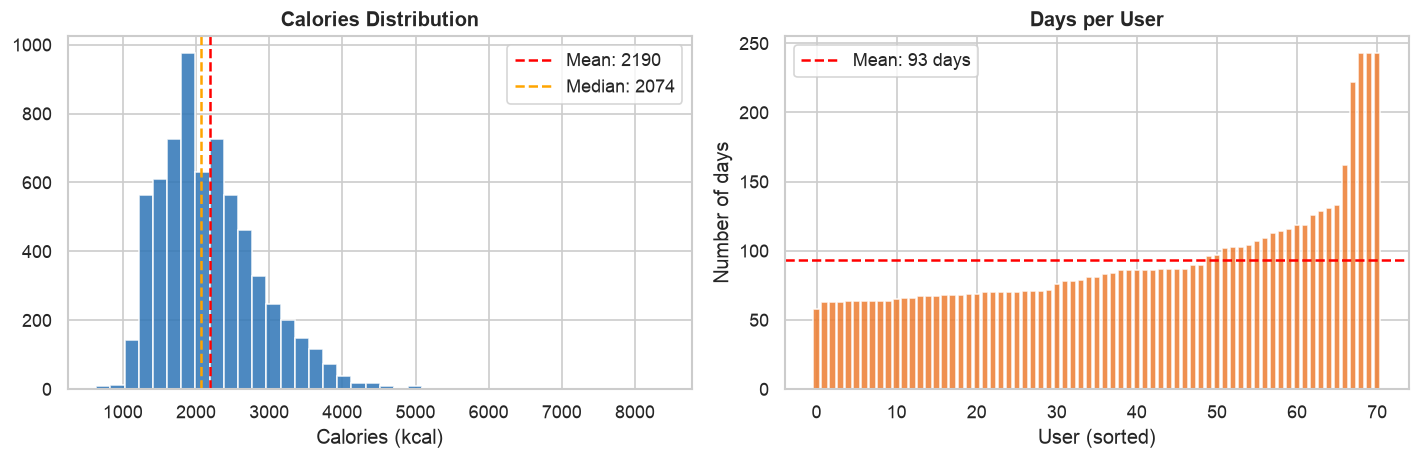

Total rows: 6638 | Users: 71
Calories — mean: 2190, std: 694, min: 635, max: 8387


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y, bins=40, edgecolor='white', color='#2E75B6', alpha=0.85)
axes[0].axvline(y.mean(), color='red', linestyle='--', label=f'Mean: {y.mean():.0f}')
axes[0].axvline(y.median(), color='orange', linestyle='--', label=f'Median: {y.median():.0f}')
axes[0].set_title('Calories Distribution', fontweight='bold')
axes[0].set_xlabel('Calories (kcal)')
axes[0].legend()

# Rows per user
rows_per_user = df.groupby('id').size().sort_values()
axes[1].bar(range(len(rows_per_user)), rows_per_user.values, color='#ED7D31', alpha=0.85)
axes[1].axhline(rows_per_user.mean(), color='red', linestyle='--', label=f'Mean: {rows_per_user.mean():.0f} days')
axes[1].set_title('Days per User', fontweight='bold')
axes[1].set_xlabel('User (sorted)')
axes[1].set_ylabel('Number of days')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Total rows: {len(df)} | Users: {df["id"].nunique()}')
print(f'Calories — mean: {y.mean():.0f}, std: {y.std():.0f}, min: {y.min():.0f}, max: {y.max():.0f}')

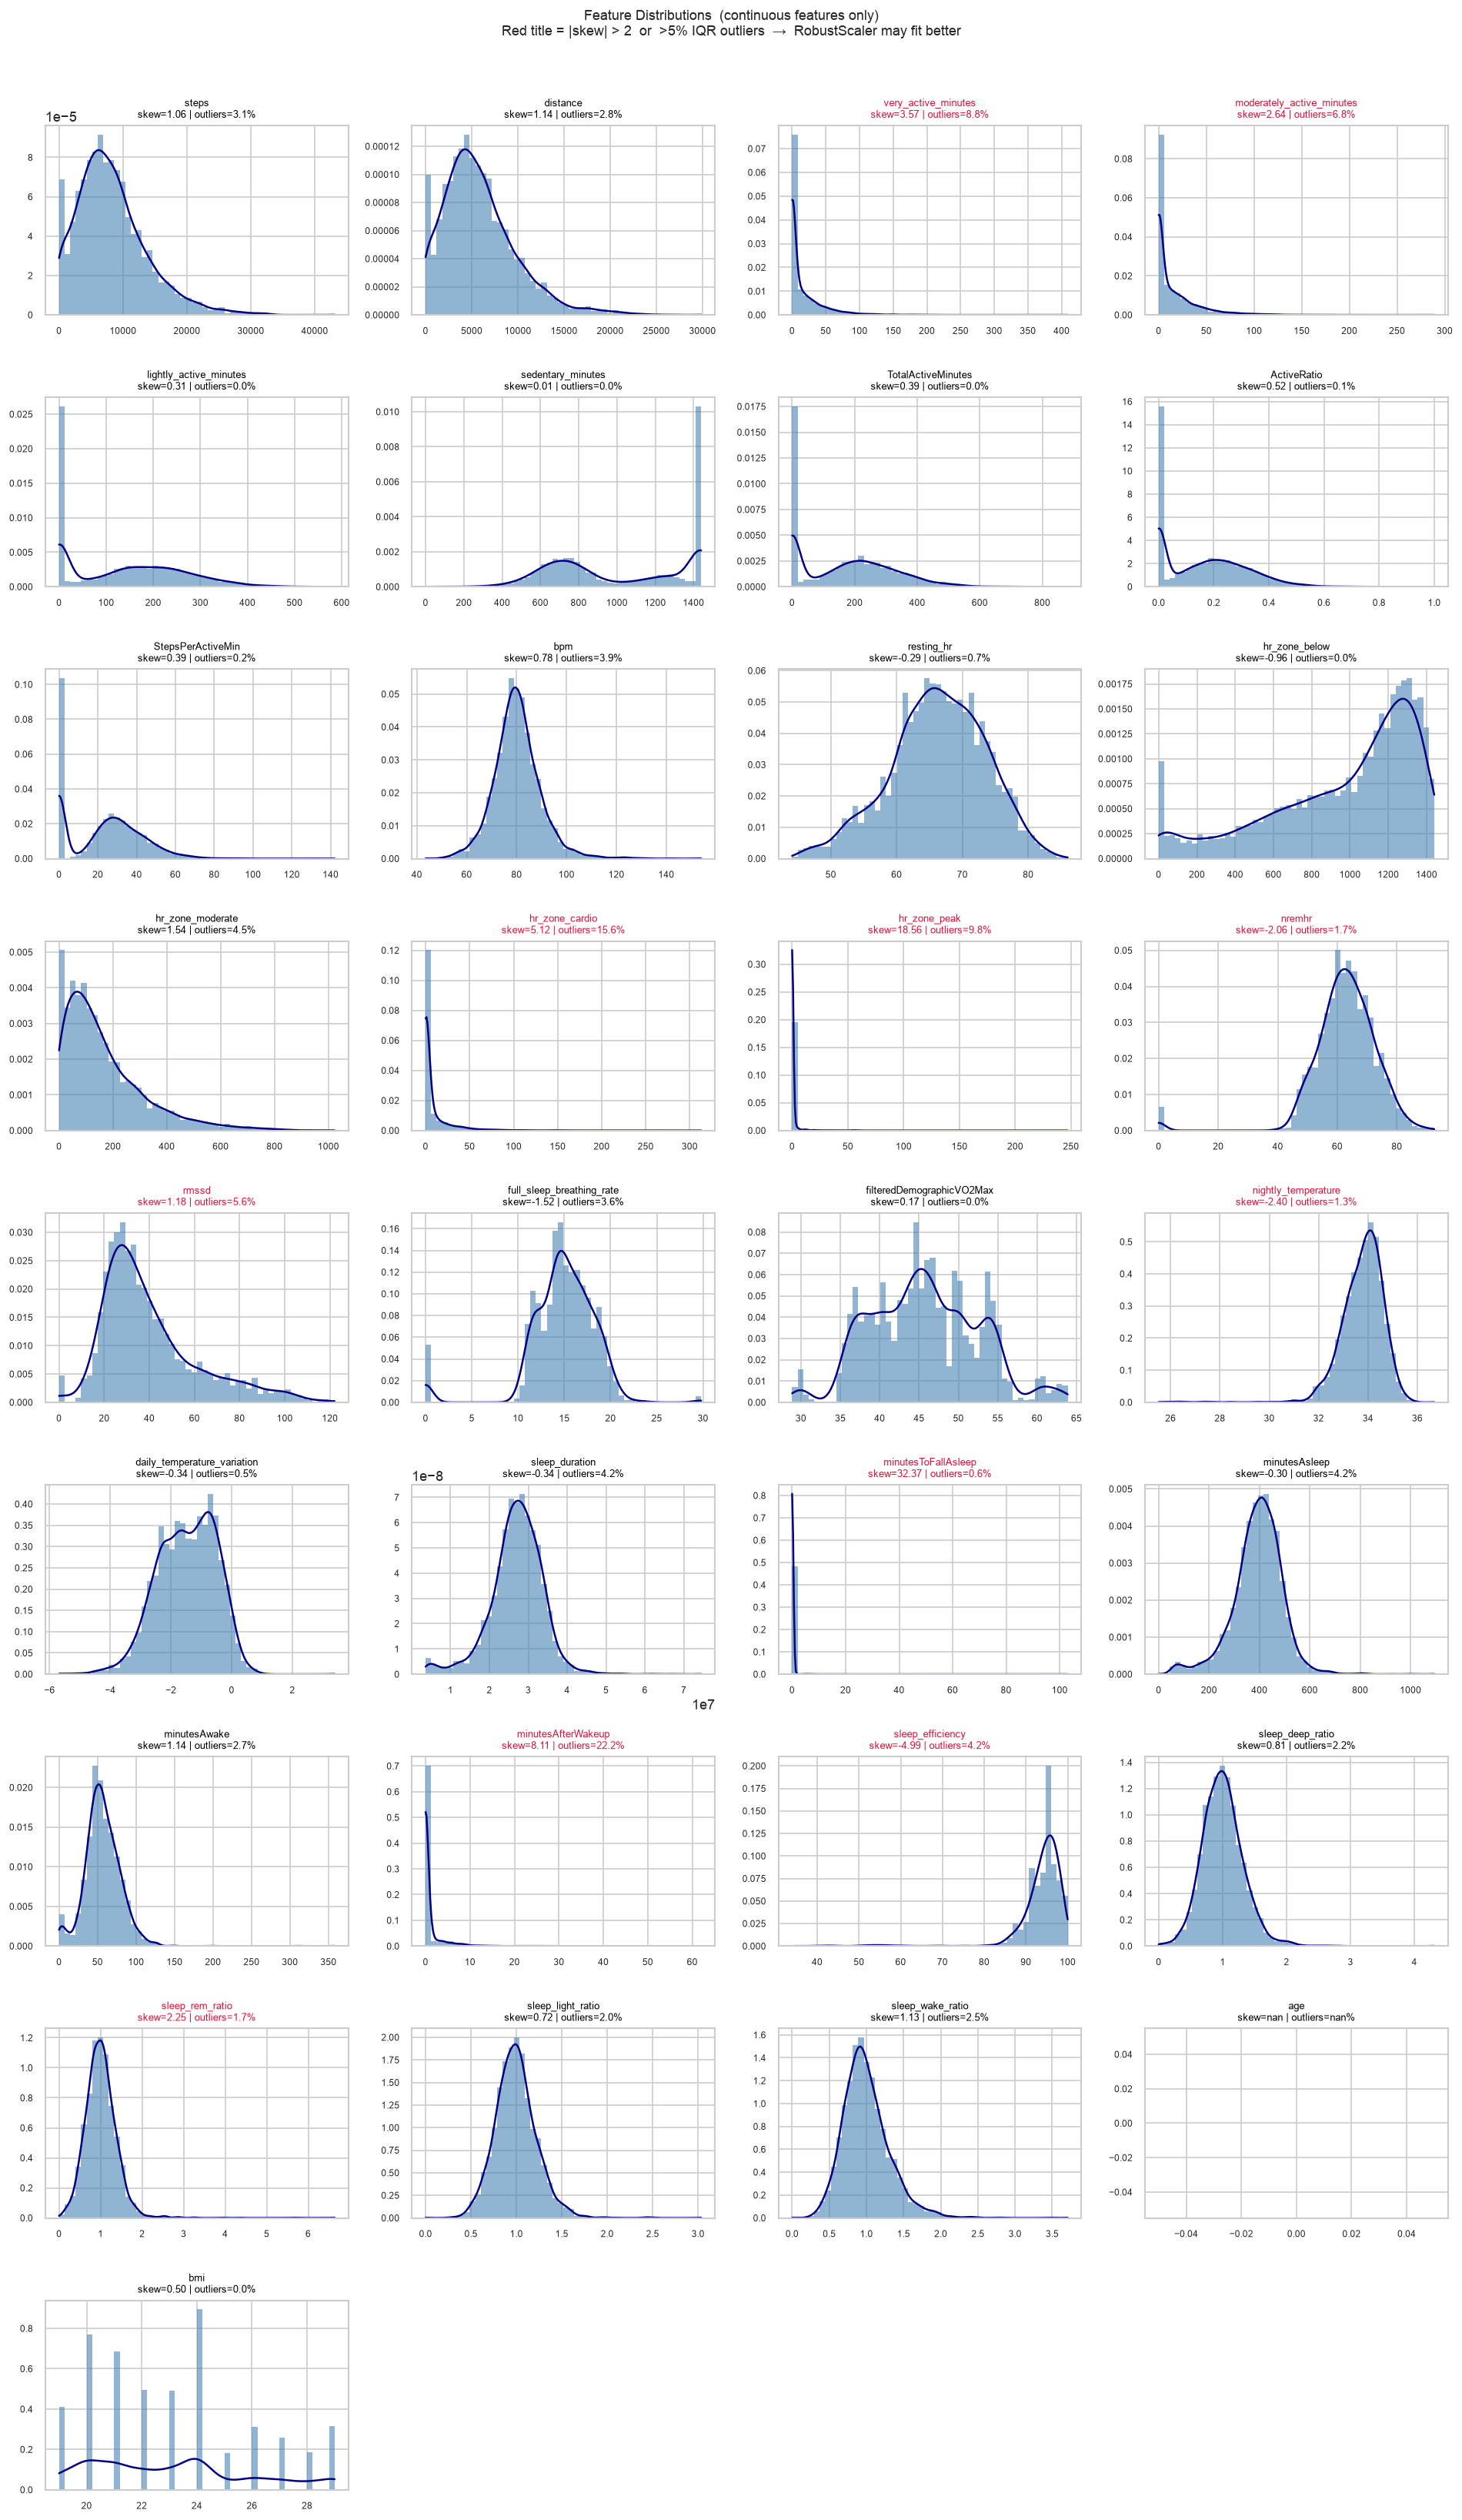

                    feature  skewness  outlier_%    recommendation
         minutesAfterWakeup      8.11       22.2      RobustScaler
             hr_zone_cardio      5.12       15.6      RobustScaler
               hr_zone_peak     18.56        9.8      RobustScaler
        very_active_minutes      3.57        8.8      RobustScaler
  moderately_active_minutes      2.64        6.8      RobustScaler
                      rmssd      1.18        5.6      RobustScaler
           hr_zone_moderate      1.54        4.5 StandardScaler OK
           sleep_efficiency     -4.99        4.2      RobustScaler
              minutesAsleep     -0.30        4.2 StandardScaler OK
             sleep_duration     -0.34        4.2 StandardScaler OK
                        bpm      0.78        3.9 StandardScaler OK
  full_sleep_breathing_rate     -1.52        3.6 StandardScaler OK
                      steps      1.06        3.1 StandardScaler OK
                   distance      1.14        2.8 StandardScale

In [7]:
# ── 16) Feature distribution plots (outlier check → StandardScaler vs RobustScaler) ──
import matplotlib.pyplot as plt
from scipy import stats

# Exclude binary/categorical features
skip_cols = ['IsWeekend', 'DayOfWeek', 'mindfulness_session', 'gender_binary',
             'ALERT', 'HAPPY', 'NEUTRAL', 'RESTED/RELAXED', 'SAD', 'TENSE/ANXIOUS', 'TIRED',
             'ENTERTAINMENT', 'GYM', 'HOME', 'HOME_OFFICE', 'OTHER', 'OUTDOORS', 'TRANSIT', 'WORK/SCHOOL']

plot_cols = [c for c in feature_cols if c not in skip_cols]

ncols = 4
nrows = -(-len(plot_cols) // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    ax = axes[i]
    data = df[col].dropna()

    skew = data.skew()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    n_outliers = ((data < q1 - 1.5 * iqr) | (data > q3 + 1.5 * iqr)).sum()
    pct_outliers = n_outliers / len(data) * 100

    ax.hist(data, bins=50, color='steelblue', alpha=0.6, density=True, edgecolor='none')
    try:
        kde_x = np.linspace(data.min(), data.max(), 300)
        kde = stats.gaussian_kde(data)
        ax.plot(kde_x, kde(kde_x), color='navy', lw=1.5)
    except Exception:
        pass

    # Red title = high skew or many outliers → RobustScaler likely better
    bad = abs(skew) > 2 or pct_outliers > 5
    ax.set_title(f'{col}\nskew={skew:.2f} | outliers={pct_outliers:.1f}%',
                 fontsize=8, color='crimson' if bad else 'black')
    ax.tick_params(labelsize=7)

# Hide unused axes
for j in range(len(plot_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    'Feature Distributions  (continuous features only)\n'
    'Red title = |skew| > 2  or  >5% IQR outliers  →  RobustScaler may fit better',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.show()

# ── Summary table ──
summary = []
for col in plot_cols:
    data = df[col].dropna()
    skew = data.skew()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    n_out = ((data < q1 - 1.5 * iqr) | (data > q3 + 1.5 * iqr)).sum()
    pct_out = n_out / len(data) * 100
    rec = 'RobustScaler' if (abs(skew) > 2 or pct_out > 5) else 'StandardScaler OK'
    summary.append({'feature': col, 'skewness': round(skew, 2),
                    'outlier_%': round(pct_out, 1), 'recommendation': rec})

dist_summary_df = pd.DataFrame(summary).sort_values('outlier_%', ascending=False)
print(dist_summary_df.to_string(index=False))


        scaler      model    MAE   RMSE     R2
StandardScaler      Ridge 324.47 456.32 0.5506
StandardScaler      Lasso 323.22 450.68 0.5626
StandardScaler ElasticNet 324.52 433.07 0.6032
  RobustScaler      Ridge 324.00 455.70 0.5522
  RobustScaler      Lasso 321.35 448.48 0.5668
  RobustScaler ElasticNet 341.02 442.29 0.5862


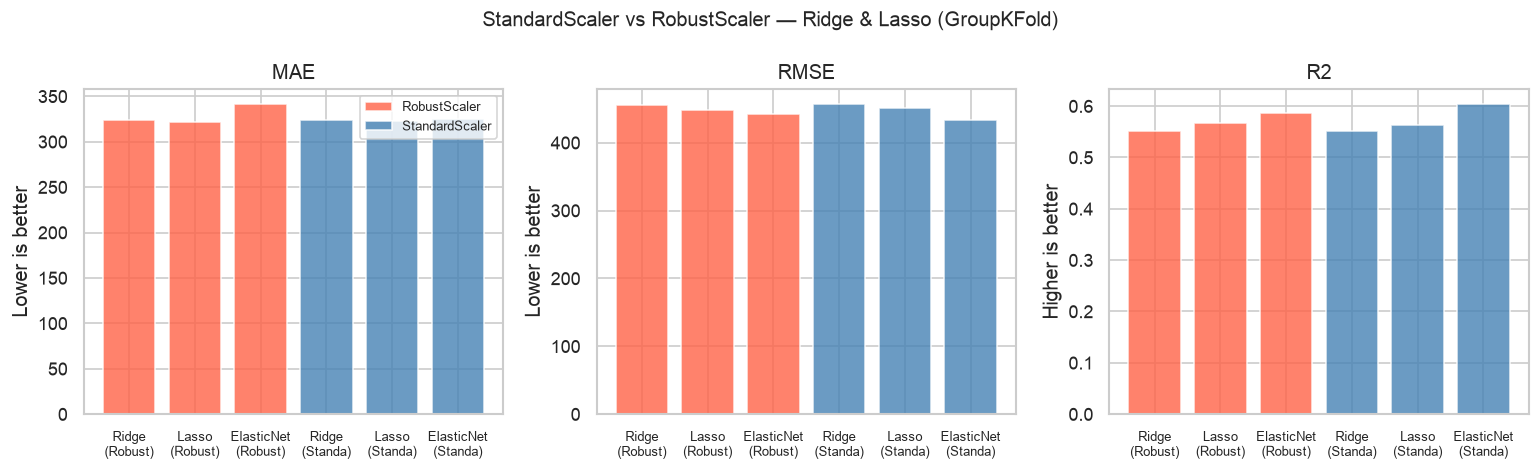

In [42]:
# ── StandardScaler vs RobustScaler — Ridge & Lasso only (GroupKFold) ──
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import GroupKFold

gkf_local = GroupKFold(n_splits=3)
from sklearn.linear_model import ElasticNet, Ridge, Lasso

scaler_results = []

for scaler_name, scaler_obj in [('StandardScaler', StandardScaler()), ('RobustScaler', RobustScaler())]:
    for model_name, model_obj in [('Ridge', Ridge(alpha=1.0)), ('Lasso', Lasso(alpha=1.0, max_iter=5000)), ('ElasticNet', ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=5000))]:
        pipe = Pipeline([
            ('imputer', PerUserMedianImputer(feature_cols=feature_cols)),
            ('scaler',  scaler_obj),
            ('model',   model_obj),
        ])
        maes, rmses, r2s = [], [], []
        for train_idx, test_idx in gkf_local.split(X, y, groups):
            pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
            y_pred = pipe.predict(X.iloc[test_idx])
            maes.append(mean_absolute_error(y.iloc[test_idx], y_pred))
            rmses.append(mean_squared_error(y.iloc[test_idx], y_pred) ** 0.5)
            r2s.append(r2_score(y.iloc[test_idx], y_pred))
        scaler_results.append({
            'scaler': scaler_name, 'model': model_name,
            'MAE':  round(np.mean(maes), 2),
            'RMSE': round(np.mean(rmses), 2),
            'R2':   round(np.mean(r2s), 4),
        })

results_df = pd.DataFrame(scaler_results)
print(results_df.to_string(index=False))

# ── Visual comparison ──
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metrics = ['MAE', 'RMSE', 'R2']
colors  = {'StandardScaler': 'steelblue', 'RobustScaler': 'tomato'}

for ax, metric in zip(axes, metrics):
    for scaler_name, grp in results_df.groupby('scaler'):
        ax.bar(grp['model'] + f'\n({scaler_name[:6]})',
               grp[metric], color=colors[scaler_name], alpha=0.8, label=scaler_name)
    ax.set_title(metric)
    ax.tick_params(axis='x', labelsize=8)
    if metric in ('MAE', 'RMSE'):
        ax.set_ylabel('Lower is better')
    else:
        ax.set_ylabel('Higher is better')

axes[0].legend(fontsize=8)
fig.suptitle('StandardScaler vs RobustScaler — Ridge & Lasso (GroupKFold)', fontsize=12)
plt.tight_layout()
plt.show()


=== Scaling Sensitivity — Model Comparison ===
                  Relies on Scaling  KFold MAE  GKF MAE                                                                             Why
Model                                                                                                                                  
Linear Regression               Yes      252.1    323.7                  Gradient descent / OLS — features on different scales dominate
Ridge                           Yes      252.2    324.5  L2 penalty shrinks all weights equally — scale affects regularisation strength
Lasso                           Yes      253.0    323.2               L1 penalty — same issue; unscaled features get unfairly penalised
ElasticNet                      Yes        NaN      NaN        L1+L2 penalty — same as Lasso/Ridge; scaling ensures fair regularisation
Random Forest                    No      109.4    288.5           Splits on thresholds — monotone transforms of features change nothing
G

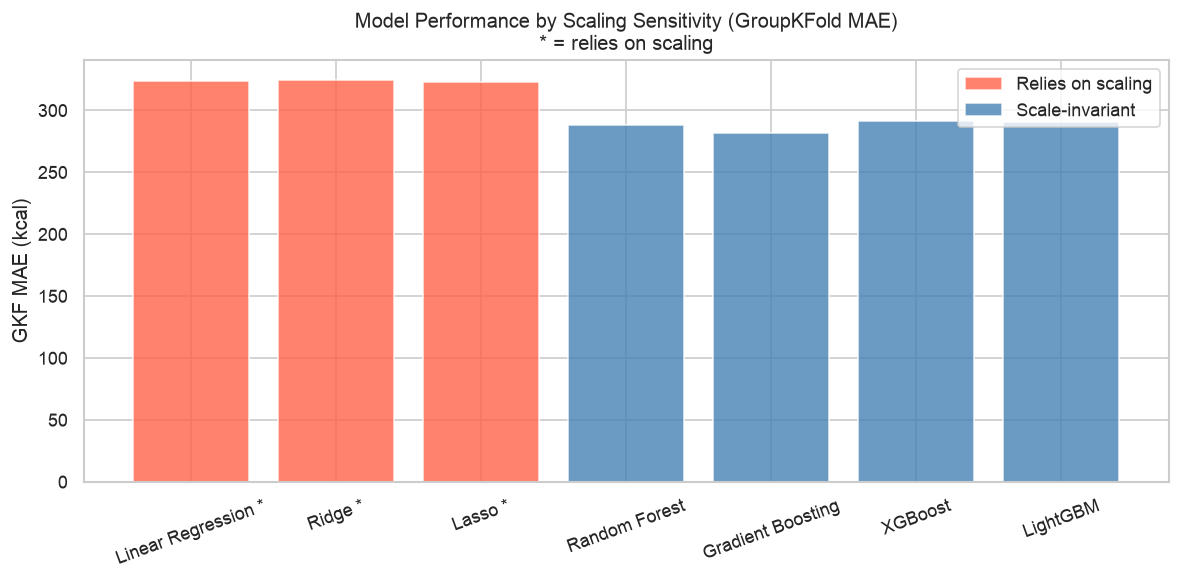

In [9]:
# ── Scaling sensitivity comparison table ──
scale_info = {
    'Linear Regression': {'relies_on_scaling': True,  'why': 'Gradient descent / OLS — features on different scales dominate'},
    'Ridge':              {'relies_on_scaling': True,  'why': 'L2 penalty shrinks all weights equally — scale affects regularisation strength'},
    'Lasso':              {'relies_on_scaling': True,  'why': 'L1 penalty — same issue; unscaled features get unfairly penalised'},
    'ElasticNet':         {'relies_on_scaling': True,  'why': 'L1+L2 penalty — same as Lasso/Ridge; scaling ensures fair regularisation'},
    'Random Forest':      {'relies_on_scaling': False, 'why': 'Splits on thresholds — monotone transforms of features change nothing'},
    'Gradient Boosting':  {'relies_on_scaling': False, 'why': 'Same as Random Forest — tree splits are scale-invariant'},
    'XGBoost':            {'relies_on_scaling': False, 'why': 'Tree-based — scaling has zero effect on predictions'},
    'LightGBM':           {'relies_on_scaling': False, 'why': 'Tree-based — scaling has zero effect on predictions'},
}

# Read MAE from results dict if already computed (run cell 14 first), else use hardcoded fallback
_kfold_fallback = {
    'Linear Regression': 252.1, 'Ridge': 252.2, 'Lasso': 253.0, 'ElasticNet': None,
    'Random Forest': 109.4, 'Gradient Boosting': 155.4, 'XGBoost': 108.6, 'LightGBM': 105.7,
}
_gkf_fallback = {
    'Linear Regression': 323.7, 'Ridge': 324.5, 'Lasso': 323.2, 'ElasticNet': None,
    'Random Forest': 288.5, 'Gradient Boosting': 281.5, 'XGBoost': 291.3, 'LightGBM': 290.8,
}

try:
    kfold_mae = {k: results[k]['MAE'] for k in scale_info if k in results}
    gkf_mae   = {k: gkf_default[k][0] for k in scale_info if k in gkf_default}
except NameError:
    kfold_mae = _kfold_fallback
    gkf_mae   = _gkf_fallback

rows = []
for model, info in scale_info.items():
    rows.append({
        'Model':             model,
        'Relies on Scaling': 'Yes' if info['relies_on_scaling'] else 'No',
        'KFold MAE':         kfold_mae.get(model),
        'GKF MAE':           gkf_mae.get(model),
        'Why':               info['why'],
    })

cmp_df = pd.DataFrame(rows).set_index('Model')
print('=== Scaling Sensitivity — Model Comparison ===')
print(cmp_df.to_string())

# ── Visual ──
plot_df = cmp_df.dropna(subset=['GKF MAE'])
fig, ax = plt.subplots(figsize=(10, 5))
scale_yes = plot_df[plot_df['Relies on Scaling'] == 'Yes']
scale_no  = plot_df[plot_df['Relies on Scaling'] == 'No']

ax.bar([m + ' *' for m in scale_yes.index], scale_yes['GKF MAE'],
       color='tomato', alpha=0.8, label='Relies on scaling')
ax.bar(list(scale_no.index), scale_no['GKF MAE'],
       color='steelblue', alpha=0.8, label='Scale-invariant')

ax.set_ylabel('GKF MAE (kcal)')
ax.set_title('Model Performance by Scaling Sensitivity (GroupKFold MAE)\n* = relies on scaling')
ax.legend()
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


## 4. Baseline Models

> 🔵 **Evaluation: 5-Fold CV (KFold)**  
> Note: KFold has user overlap + temporal leakage → optimistic. Fixed in Section 6.

In [10]:
kf = KFold(n_splits=3, shuffle=True, random_state=42)

base_models = {
    'Linear Regression': LinearRegression(),
    'Ridge':             Ridge(alpha=1.0),
    'Lasso':             Lasso(alpha=1.0),
    'ElasticNet':        ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=5000),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost':           XGBRegressor(n_estimators=100, random_state=42, verbosity=0, n_jobs=2),
    'LightGBM':          lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1, n_jobs=2),
}

results = {}
for name, model in base_models.items():
    pipe = Pipeline([
        ('imputer', PerUserMedianImputer(feature_cols=feature_cols)),
        ('scaler',  StandardScaler()),
        ('model',   model),
    ])
    cv_res = cross_validate(pipe, X, y, cv=kf, n_jobs=2, scoring={
        'mae':  'neg_mean_absolute_error',
        'rmse': 'neg_mean_squared_error',
        'r2':   'r2',
    })
    mae  = -cv_res['test_mae'].mean()
    rmse = np.sqrt(-cv_res['test_rmse'].mean())
    r2   = cv_res['test_r2'].mean()
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f'{name:<22} | MAE={mae:.1f}±{(-cv_res["test_mae"]).std():.1f}  '
          f'RMSE={rmse:.1f}  R²={r2:.3f}±{cv_res["test_r2"].std():.3f}')


Linear Regression      | MAE=252.1±2.6  RMSE=351.3  R²=0.744±0.004
Ridge                  | MAE=252.2±2.6  RMSE=350.5  R²=0.745±0.004
Lasso                  | MAE=253.0±3.0  RMSE=349.5  R²=0.746±0.005
ElasticNet             | MAE=285.7±4.1  RMSE=380.8  R²=0.699±0.004
Random Forest          | MAE=109.4±1.1  RMSE=215.5  R²=0.903±0.007
Gradient Boosting      | MAE=155.4±1.3  RMSE=247.1  R²=0.873±0.003
XGBoost                | MAE=108.6±4.1  RMSE=201.5  R²=0.916±0.007
LightGBM               | MAE=105.7±2.6  RMSE=197.3  R²=0.919±0.006


In [11]:
# Summary table
baseline_df = pd.DataFrame(results).T[['MAE', 'RMSE', 'R2']].round(3)
baseline_df = baseline_df.sort_values('MAE')
print('=== Baseline Results (5-Fold CV) ===')
print(baseline_df.to_string())

=== Baseline Results (5-Fold CV) ===
                       MAE     RMSE     R2
LightGBM           105.699  197.321  0.919
XGBoost            108.626  201.533  0.916
Random Forest      109.364  215.521  0.903
Gradient Boosting  155.390  247.085  0.873
Linear Regression  252.129  351.339  0.744
Ridge              252.198  350.479  0.745
Lasso              252.973  349.522  0.746
ElasticNet         285.739  380.812  0.699


## 5. Hyperparameter Tuning with Optuna — KFold

> 🔵 **Evaluation: 5-Fold CV (KFold)**  
> Optimistic due to user overlap + temporal leakage. See Section 6 for honest evaluation.

In [12]:
all_features = feature_cols  # alias for Pylance
N_TRIALS = 20

# ── Per-model Optuna objective factories ──────────────────────────────────
def make_obj_kfold(model_fn):
    def objective(trial):
        pipe = Pipeline([
            ('imputer', PerUserMedianImputer(feature_cols=feature_cols)),
            ('scaler',  StandardScaler()),
            ('model',   model_fn(trial)),
        ])
        return cross_val_score(pipe, X, y, cv=kf,
                               scoring='neg_mean_absolute_error', n_jobs=2).mean()
    return objective

def model_ridge(trial):
    return Ridge(alpha=trial.suggest_float('alpha', 1e-3, 1e3, log=True))

def model_lasso(trial):
    return Lasso(alpha=trial.suggest_float('alpha', 1e-3, 1e2, log=True), max_iter=5000)
def model_elasticnet(trial):
    return ElasticNet(
        alpha     = trial.suggest_float('alpha', 1e-3, 1e2, log=True),
        l1_ratio  = trial.suggest_float('l1_ratio', 0.01, 0.99),
        max_iter  = 5000)


def model_rf(trial):
    return RandomForestRegressor(
        n_estimators      = trial.suggest_int('n_estimators', 50, 400),
        max_depth         = trial.suggest_int('max_depth', 3, 20),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 10),
        max_features      = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.8]),
        random_state=42, n_jobs=-1)

def model_gb(trial):
    return GradientBoostingRegressor(
        n_estimators      = trial.suggest_int('n_estimators', 50, 500),
        max_depth         = trial.suggest_int('max_depth', 2, 6),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
        random_state=42)

def model_xgb(trial):
    return XGBRegressor(
        n_estimators     = trial.suggest_int('n_estimators', 50, 500),
        max_depth        = trial.suggest_int('max_depth', 2, 8),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
        reg_alpha        = trial.suggest_float('reg_alpha', 0.0, 5.0),
        reg_lambda       = trial.suggest_float('reg_lambda', 1.0, 10.0),
        random_state=42, verbosity=0, n_jobs=2)

def model_lgbm(trial):
    return lgb.LGBMRegressor(
        n_estimators      = trial.suggest_int('n_estimators', 50, 500),
        max_depth         = trial.suggest_int('max_depth', 2, 8),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_samples = trial.suggest_int('min_child_samples', 5, 50),
        reg_alpha         = trial.suggest_float('reg_alpha', 0.0, 5.0),
        reg_lambda        = trial.suggest_float('reg_lambda', 1.0, 10.0),
        random_state=42, verbose=-1, n_jobs=2)

model_fns = {
    'Ridge':             model_ridge,
    'Lasso':             model_lasso,
    'ElasticNet':        model_elasticnet,
    'Random Forest':     model_rf,
    'Gradient Boosting': model_gb,
    'XGBoost':           model_xgb,
    'LightGBM':          model_lgbm,
}

# ── Run Optuna (KFold) for all tunable models ────────────────────────────
studies_kfold = {}
print(f'Tuning all models ({N_TRIALS} Optuna trials each, KFold)...')
for name, fn in model_fns.items():
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(make_obj_kfold(fn), n_trials=N_TRIALS, n_jobs=1, show_progress_bar=False)
    studies_kfold[name] = study
    print(f'  {name:<22} best KFold MAE={-study.best_value:.1f}')
studies_kfold['Linear Regression'] = None  # no hyperparams
print('Done!')


Tuning all models (20 Optuna trials each, KFold)...
  Ridge                  best KFold MAE=252.1
  Lasso                  best KFold MAE=252.1
  ElasticNet             best KFold MAE=252.1
  Random Forest          best KFold MAE=118.6
  Gradient Boosting      best KFold MAE=97.9
  XGBoost                best KFold MAE=92.9
  LightGBM               best KFold MAE=102.0
Done!


## 6. Fix CV — GroupKFold by User

> 🟠 **Evaluation: GroupKFold (5 splits)**  
> Each fold holds out ~14 users completely unseen in training.  
> No user overlap → more honest for generalization to new users.

| CV Method | User overlap | Temporal leakage |
|---|---|---|
| KFold | ⚠️ Yes | ⚠️ Yes |
| GroupKFold | ✅ No | ⚠️ Yes (but lag features not used) |

In [13]:
gkf = GroupKFold(n_splits=3)

def make_pipe(model):
    return Pipeline([
        ('imputer', PerUserMedianImputer(feature_cols=feature_cols)),
        ('scaler',  StandardScaler()),
        ('model',   model),
    ])

def gkf_eval(pipe, label):
    cv  = cross_validate(pipe, X, y, cv=gkf, groups=groups, n_jobs=2, scoring={
        'mae': 'neg_mean_absolute_error', 'rmse': 'neg_mean_squared_error', 'r2': 'r2'})
    mae  = -cv['test_mae'].mean()
    rmse = np.sqrt(-cv['test_rmse'].mean())
    r2   = cv['test_r2'].mean()
    print(f'{label:<40} MAE={mae:.1f}  RMSE={rmse:.1f}  R²={r2:.3f}')
    return mae, rmse, r2

def get_kfold_tuned_model(name):
    study = studies_kfold[name]
    if name == 'Linear Regression' or study is None:
        return LinearRegression()
    p = study.best_params
    if name == 'Ridge':             return Ridge(alpha=p['alpha'])
    if name == 'Lasso':             return Lasso(alpha=p['alpha'], max_iter=5000)
    if name == 'ElasticNet':        return ElasticNet(alpha=p['alpha'], l1_ratio=p['l1_ratio'], max_iter=5000)
    if name == 'Random Forest':     return RandomForestRegressor(**p, random_state=42, n_jobs=-1)
    if name == 'Gradient Boosting': return GradientBoostingRegressor(**p, random_state=42)
    if name == 'XGBoost':           return XGBRegressor(**p, random_state=42, verbosity=0, n_jobs=2)
    if name == 'LightGBM':          return lgb.LGBMRegressor(**p, random_state=42, verbose=-1, n_jobs=2)

# Default models (same as Section 4)
default_models = {
    'Linear Regression': LinearRegression(),
    'Ridge':             Ridge(alpha=1.0),
    'Lasso':             Lasso(alpha=1.0),
    'ElasticNet':        ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=5000),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost':           XGBRegressor(n_estimators=100, random_state=42, verbosity=0, n_jobs=2),
    'LightGBM':          lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1, n_jobs=2),
}

print('GroupKFold evaluation — Default models (no user overlap):')
print('-' * 70)
gkf_default = {}
for name, model in default_models.items():
    gkf_default[name] = gkf_eval(make_pipe(model), f'{name} (default)')

print('\nGroupKFold evaluation — KFold-tuned models:')
print('-' * 70)
gkf_kfold_tuned = {}
tuned_pipes_kfold = {}
for name in default_models:
    pipe = make_pipe(get_kfold_tuned_model(name))
    tuned_pipes_kfold[name] = pipe
    gkf_kfold_tuned[name] = gkf_eval(pipe, f'{name} (KFold-tuned)')

# Backwards compat for cells 22-27
pipe_lgbm        = make_pipe(default_models['LightGBM'])
pipe_kfold_tuned = tuned_pipes_kfold['XGBoost']


GroupKFold evaluation — Default models (no user overlap):
----------------------------------------------------------------------
Linear Regression (default)              MAE=323.7  RMSE=474.5  R²=0.540
Ridge (default)                          MAE=324.5  RMSE=469.1  R²=0.551
Lasso (default)                          MAE=323.2  RMSE=462.7  R²=0.562
ElasticNet (default)                     MAE=324.5  RMSE=437.0  R²=0.603
Random Forest (default)                  MAE=288.5  RMSE=426.3  R²=0.627
Gradient Boosting (default)              MAE=281.5  RMSE=416.1  R²=0.646
XGBoost (default)                        MAE=291.3  RMSE=429.9  R²=0.623
LightGBM (default)                       MAE=290.8  RMSE=427.1  R²=0.626

GroupKFold evaluation — KFold-tuned models:
----------------------------------------------------------------------
Linear Regression (KFold-tuned)          MAE=323.7  RMSE=474.5  R²=0.540
Ridge (KFold-tuned)                      MAE=323.7  RMSE=474.5  R²=0.540
Lasso (KFold-tuned)      

In [14]:
# Compare KFold vs GroupKFold for all models
comparison = pd.DataFrame({
    'KFold MAE (default)':         [results[n]['MAE']         for n in default_models],
    'GKF MAE (default)':           [gkf_default[n][0]         for n in default_models],
    'GKF MAE (KFold-tuned)':       [gkf_kfold_tuned[n][0]     for n in default_models],
}, index=list(default_models.keys()))
comparison['Leakage Gap'] = (comparison['GKF MAE (default)'] -
                              comparison['KFold MAE (default)']).round(1)
print(comparison.round(1).to_string())
print()
print('Leakage Gap = GKF MAE - KFold MAE  (positive = KFold was overoptimistic)')


                   KFold MAE (default)  GKF MAE (default)  GKF MAE (KFold-tuned)  Leakage Gap
Linear Regression                252.1              323.7                  323.7         71.6
Ridge                            252.2              324.5                  323.7         72.3
Lasso                            253.0              323.2                  324.2         70.2
ElasticNet                       285.7              324.5                  324.1         38.8
Random Forest                    109.4              288.5                  283.6        179.1
Gradient Boosting                155.4              281.5                  282.9        126.2
XGBoost                          108.6              291.3                  284.1        182.7
LightGBM                         105.7              290.8                  292.5        185.1

Leakage Gap = GKF MAE - KFold MAE  (positive = KFold was overoptimistic)


## 7. Retune Optuna with GroupKFold

> 🟠 **Evaluation: GroupKFold** — tune with honest CV method

In [15]:
def make_obj_gkf(model_fn):
    def objective(trial):
        pipe = Pipeline([
            ('imputer', PerUserMedianImputer(feature_cols=feature_cols)),
            ('scaler',  StandardScaler()),
            ('model',   model_fn(trial)),
        ])
        return cross_val_score(pipe, X, y, cv=gkf, groups=groups,
                               scoring='neg_mean_absolute_error', n_jobs=2).mean()
    return objective

studies_gkf = {}
print(f'Retuning all models ({N_TRIALS} trials each, GroupKFold)...')
for name, fn in model_fns.items():
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(make_obj_gkf(fn), n_trials=N_TRIALS, n_jobs=1, show_progress_bar=False)
    studies_gkf[name] = study
    kf_mae  = -studies_kfold[name].best_value
    gkf_mae = gkf_kfold_tuned[name][0]
    print(f'  {name:<22} KFold-tuned GKF MAE={gkf_mae:.1f}  '
          f'GKF-tuned GKF MAE={-study.best_value:.1f}  '
          f'Δ={gkf_mae - (-study.best_value):+.1f}')
studies_gkf['Linear Regression'] = None  # no hyperparams
print('Done!')


Retuning all models (20 trials each, GroupKFold)...
  Ridge                  KFold-tuned GKF MAE=323.7  GKF-tuned GKF MAE=321.5  Δ=+2.2
  Lasso                  KFold-tuned GKF MAE=324.2  GKF-tuned GKF MAE=310.4  Δ=+13.8
  ElasticNet             KFold-tuned GKF MAE=324.1  GKF-tuned GKF MAE=321.0  Δ=+3.0
  Random Forest          KFold-tuned GKF MAE=283.6  GKF-tuned GKF MAE=281.1  Δ=+2.5
  Gradient Boosting      KFold-tuned GKF MAE=282.9  GKF-tuned GKF MAE=276.1  Δ=+6.8
  XGBoost                KFold-tuned GKF MAE=284.1  GKF-tuned GKF MAE=278.9  Δ=+5.2
  LightGBM               KFold-tuned GKF MAE=292.5  GKF-tuned GKF MAE=281.9  Δ=+10.5
Done!


## 8. Final Summary — All Methods

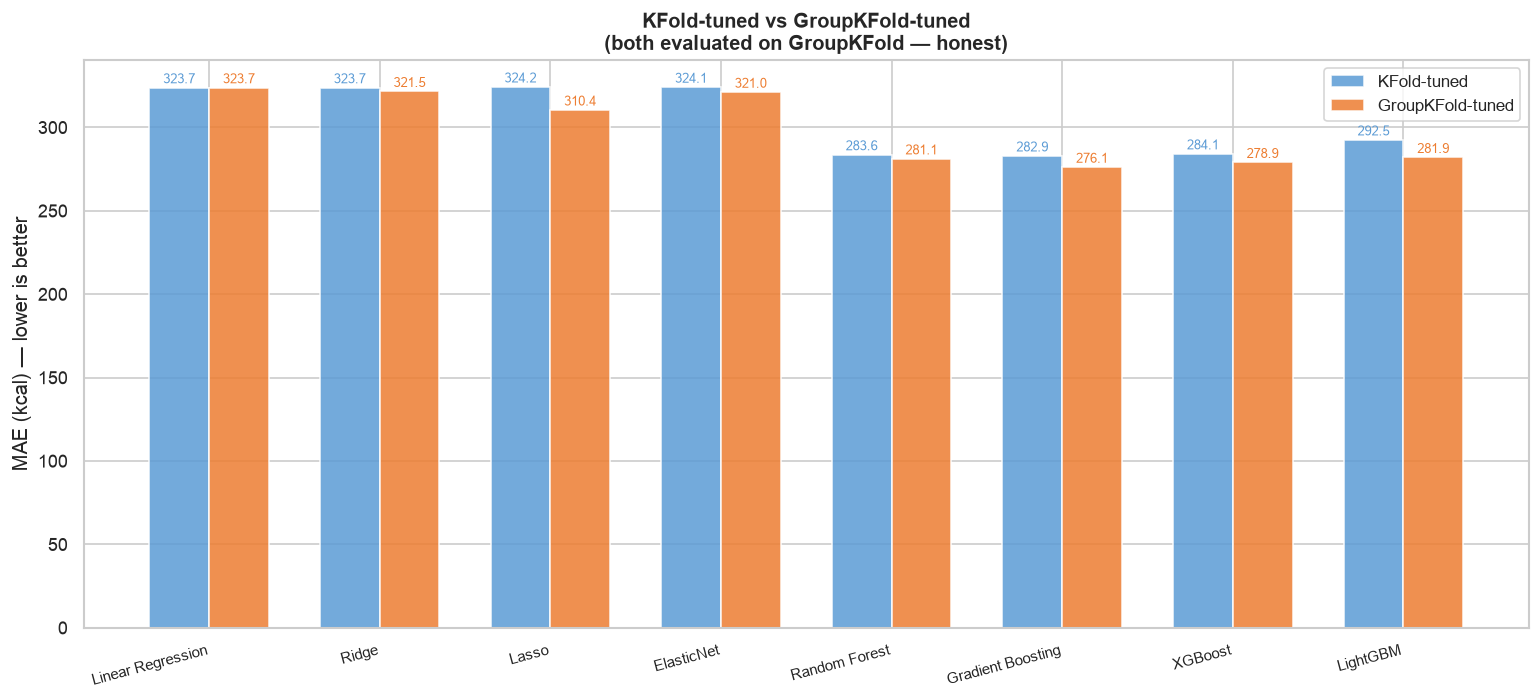

                   KFold-tuned MAE  GKF-tuned MAE  Diff (GKF-KF)
Model                                                           
Linear Regression            323.7          323.7            0.0
Ridge                        323.7          321.5           -2.2
Lasso                        324.2          310.4          -13.8
ElasticNet                   324.1          321.0           -3.0
Random Forest                283.6          281.1           -2.5
Gradient Boosting            282.9          276.1           -6.8
XGBoost                      284.1          278.9           -5.2
LightGBM                     292.5          281.9          -10.5

Negative diff = GKF-tuned better | Positive diff = KFold-tuned better


In [44]:
# ── KFold-tuned vs GroupKFold-tuned — compare on GroupKFold ──────────────
model_names = list(default_models.keys())
kf_maes, gkf_maes = [], []

for name in model_names:
    # KFold-tuned → evaluate on GroupKFold
    pipe_kf = make_pipe(get_kfold_tuned_model(name))
    cv_kf = cross_validate(pipe_kf, X, y, cv=gkf, groups=groups, n_jobs=2,
                           scoring={'mae': 'neg_mean_absolute_error'})
    kf_maes.append(-cv_kf['test_mae'].mean())

    # GroupKFold-tuned → evaluate on GroupKFold
    pipe_gkf = make_pipe(get_gkf_tuned_model(name))
    cv_gkf = cross_validate(pipe_gkf, X, y, cv=gkf, groups=groups, n_jobs=2,
                            scoring={'mae': 'neg_mean_absolute_error'})
    gkf_maes.append(-cv_gkf['test_mae'].mean())

# ── Plot ──────────────────────────────────────────────────────────────────
x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, kf_maes,  width, label='KFold-tuned',      color='#5B9BD5', alpha=0.85)
bars2 = ax.bar(x + width/2, gkf_maes, width, label='GroupKFold-tuned', color='#ED7D31', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('MAE (kcal) — lower is better')
ax.set_title('KFold-tuned vs GroupKFold-tuned\n(both evaluated on GroupKFold — honest)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8, color='#5B9BD5')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8, color='#ED7D31')

plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────
diff_df = pd.DataFrame({
    'Model':           model_names,
    'KFold-tuned MAE': [round(m, 1) for m in kf_maes],
    'GKF-tuned MAE':   [round(m, 1) for m in gkf_maes],
    'Diff (GKF-KF)':   [round(g-k, 1) for k, g in zip(kf_maes, gkf_maes)],
}).set_index('Model')
print(diff_df.to_string())
print()
print("Negative diff = GKF-tuned better | Positive diff = KFold-tuned better")


In [45]:
def get_gkf_tuned_model(name):
    study = studies_gkf[name]
    if name == 'Linear Regression' or study is None:
        return LinearRegression()
    p = study.best_params
    if name == 'Ridge':             return Ridge(alpha=p['alpha'])
    if name == 'Lasso':             return Lasso(alpha=p['alpha'], max_iter=5000)
    if name == 'ElasticNet':        return ElasticNet(alpha=p['alpha'], l1_ratio=p['l1_ratio'], max_iter=5000)
    if name == 'Random Forest':     return RandomForestRegressor(**p, random_state=42, n_jobs=-1)
    if name == 'Gradient Boosting': return GradientBoostingRegressor(**p, random_state=42)
    if name == 'XGBoost':           return XGBRegressor(**p, random_state=42, verbosity=0, n_jobs=2)
    if name == 'LightGBM':          return lgb.LGBMRegressor(**p, random_state=42, verbose=-1, n_jobs=2)

print(f'{"Model":<25} {"KFold MAE":>12} {"GKF MAE (default)":>18} '
      f'{"GKF MAE (GKF-tuned)":>22} {"GKF R²":>10}')
print('-' * 95)

tuned_pipes_gkf = {}
summary_rows = []
for name in default_models:
    pipe = make_pipe(get_gkf_tuned_model(name))
    tuned_pipes_gkf[name] = pipe
    cv_res  = cross_validate(pipe, X, y, cv=gkf, groups=groups, n_jobs=2,
                             scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2'})
    gkf_mae = -cv_res['test_mae'].mean()
    gkf_r2  =  cv_res['test_r2'].mean()
    kf_mae      = results[name]['MAE']
    def_gkf_mae = gkf_default[name][0]
    print(f'{name:<25} {kf_mae:>12.1f} {def_gkf_mae:>18.1f} {gkf_mae:>22.1f} {gkf_r2:>10.3f}')
    summary_rows.append({'Model': name, 'KFold MAE': kf_mae,
                         'GKF MAE (default)': def_gkf_mae,
                         'GKF MAE (GKF-tuned)': gkf_mae, 'GKF R²': gkf_r2})

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print()
print('KFold       → user overlap + temporal leakage → optimistic')
print('GroupKFold  → no user overlap → honest for new user generalization')

# Backwards compat for cells 22-27 (feature importance uses XGBoost GKF-tuned)
pipe_gkf_tuned = tuned_pipes_gkf['XGBoost']


Model                        KFold MAE  GKF MAE (default)    GKF MAE (GKF-tuned)     GKF R²
-----------------------------------------------------------------------------------------------
Linear Regression                252.1              323.7                  323.7      0.540
Ridge                            252.2              324.5                  321.5      0.599
Lasso                            253.0              323.2                  310.4      0.631
ElasticNet                       285.7              324.5                  321.0      0.600
Random Forest                    109.4              288.5                  281.1      0.655
Gradient Boosting                155.4              281.5                  276.1      0.656
XGBoost                          108.6              291.3                  278.9      0.646
LightGBM                         105.7              290.8                  281.9      0.653

KFold       → user overlap + temporal leakage → optimistic
GroupKFold  → no

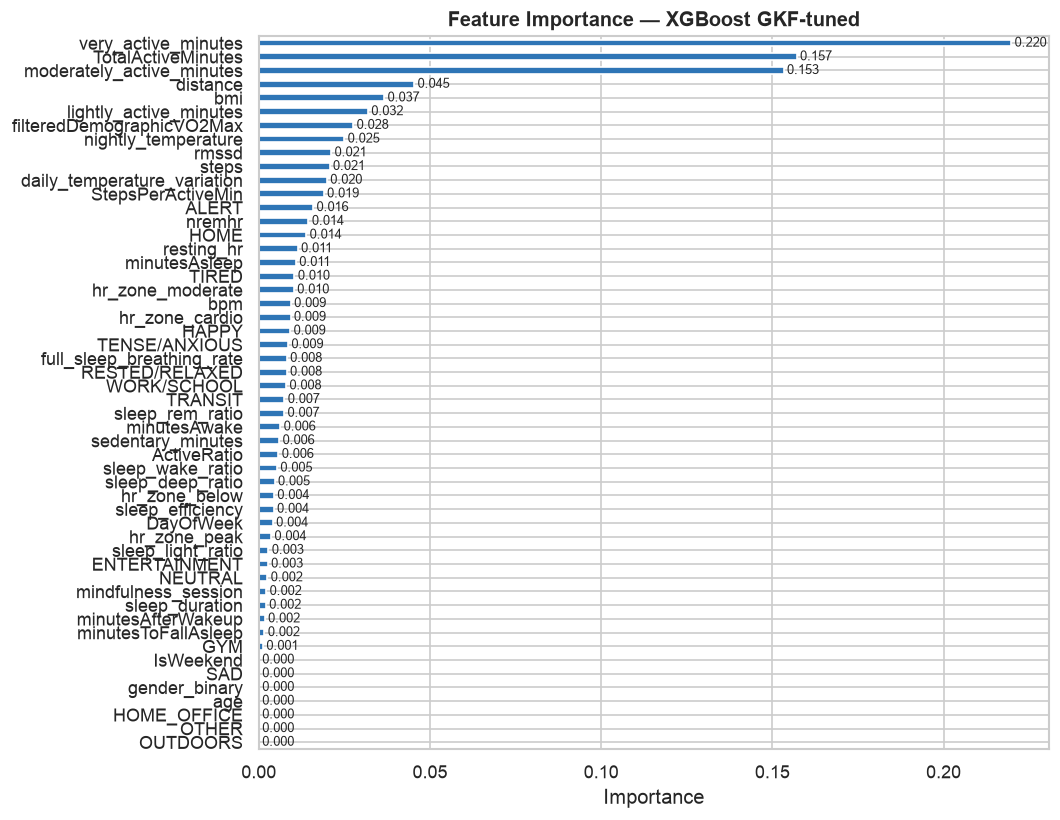

In [17]:
# Feature importance — GKF-tuned model
pipe_gkf_tuned.fit(X, y)
importances = pd.Series(
    pipe_gkf_tuned.named_steps['model'].feature_importances_,
    index=feature_cols
).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
importances.plot(kind='barh', ax=ax, color='#2E75B6')
ax.set_title('Feature Importance — XGBoost GKF-tuned', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance')
for i, v in enumerate(importances):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 9. Feature Selection — Importance ≥ 1%

> Drop features with importance < 1% and retrain with GroupKFold

Selected (30): ['very_active_minutes', 'TotalActiveMinutes', 'moderately_active_minutes', 'distance', 'bmi', 'lightly_active_minutes', 'filteredDemographicVO2Max', 'nightly_temperature', 'rmssd', 'steps', 'daily_temperature_variation', 'StepsPerActiveMin', 'ALERT', 'nremhr', 'HOME', 'resting_hr', 'minutesAsleep', 'TIRED', 'hr_zone_moderate', 'bpm', 'hr_zone_cardio', 'HAPPY', 'TENSE/ANXIOUS', 'full_sleep_breathing_rate', 'RESTED/RELAXED', 'WORK/SCHOOL', 'TRANSIT', 'sleep_rem_ratio', 'minutesAwake', 'sedentary_minutes']
Dropped  (22): ['ActiveRatio', 'sleep_wake_ratio', 'sleep_deep_ratio', 'hr_zone_below', 'sleep_efficiency', 'DayOfWeek', 'hr_zone_peak', 'sleep_light_ratio', 'ENTERTAINMENT', 'NEUTRAL', 'mindfulness_session', 'sleep_duration', 'minutesAfterWakeup', 'minutesToFallAsleep', 'GYM', 'gender_binary', 'SAD', 'IsWeekend', 'HOME_OFFICE', 'OTHER', 'OUTDOORS', 'age']
Cumulative importance of selected: 0.951


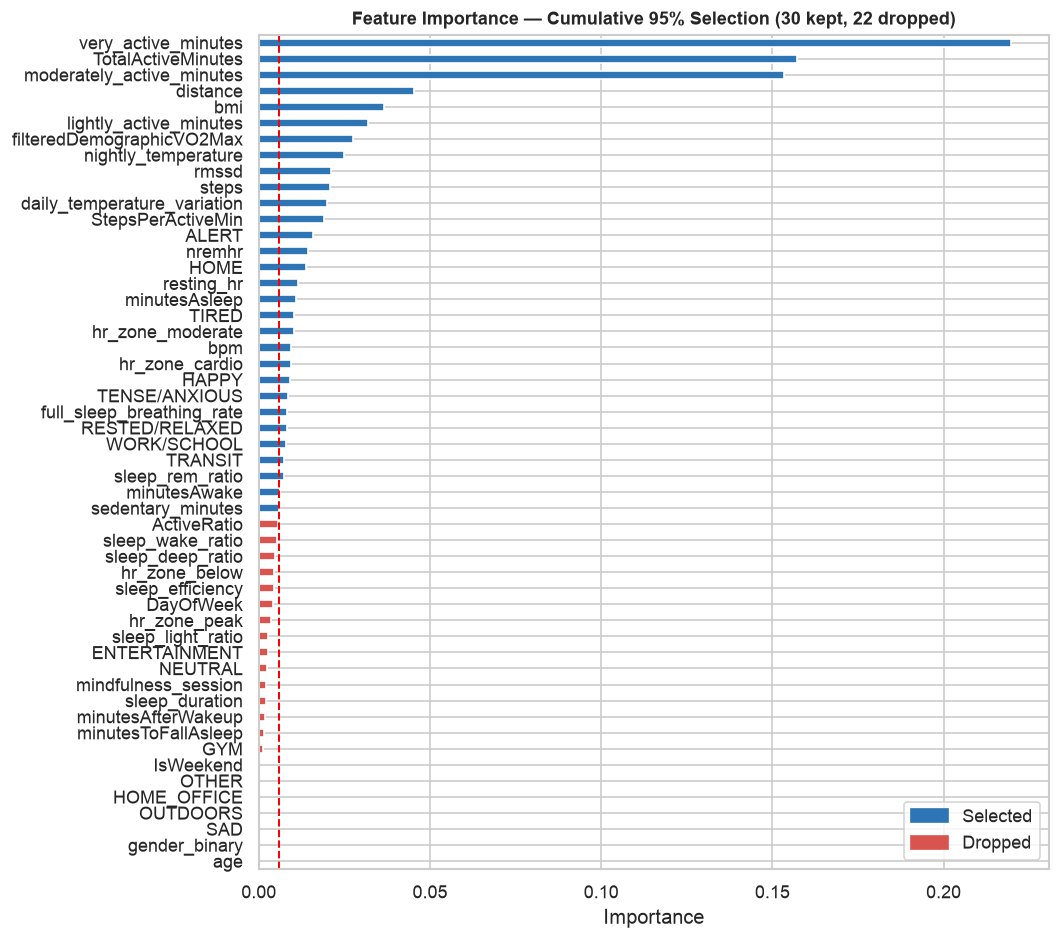

In [18]:
# Cumulative 95% threshold — keep smallest set of features that explain 95% of total importance
# Fit on full data to get importances
pipe_gkf_tuned.fit(X, y)
importances = pd.Series(
    pipe_gkf_tuned.named_steps['model'].feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

cumulative = importances.cumsum() / importances.sum()
selected_features = cumulative[cumulative <= 0.95].index.tolist()
next_feat = cumulative[cumulative > 0.95].index[0] if (cumulative > 0.95).any() else None
if next_feat:
    selected_features.append(next_feat)
dropped_features = [f for f in importances.index if f not in selected_features]

print(f'Selected ({len(selected_features)}): {selected_features}')
print(f'Dropped  ({len(dropped_features)}): {dropped_features}')
print(f'Cumulative importance of selected: {importances[selected_features].sum():.3f}')

# Plot
fig, ax = plt.subplots(figsize=(9, 8))
imp_sorted = importances.sort_values()
cutoff_val = importances[selected_features[-1]] if selected_features else 0
colors = ['#2E75B6' if f in selected_features else '#D9534F' for f in imp_sorted.index]
imp_sorted.plot(kind='barh', ax=ax, color=colors)
ax.axvline(cutoff_val, color='red', linestyle='--', linewidth=1.2, label='Cumulative 95% cutoff')
ax.set_title(f'Feature Importance — Cumulative 95% Selection ({len(selected_features)} kept, {len(dropped_features)} dropped)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Importance')
ax.legend(handles=[
    __import__("matplotlib.patches", fromlist=["Patch"]).Patch(color="#2E75B6", label="Selected"),
    __import__("matplotlib.patches", fromlist=["Patch"]).Patch(color="#D9534F", label="Dropped"),
])
plt.tight_layout()
plt.show()

In [19]:
# Retrain with selected features only
X_sel = df[['id'] + selected_features]

pipe_sel = Pipeline([
    ('imputer', PerUserMedianImputer(feature_cols=selected_features)),
    ('scaler',  StandardScaler()),
    ('model',   XGBRegressor(**studies_gkf['XGBoost'].best_params, random_state=42, verbosity=0, n_jobs=2)),
])

# Evaluate with GroupKFold
cv_sel   = cross_validate(pipe_sel, X_sel, y, cv=gkf, groups=groups, n_jobs=2, scoring={
    'mae': 'neg_mean_absolute_error', 'rmse': 'neg_mean_squared_error', 'r2': 'r2'})
mae_sel  = -cv_sel['test_mae'].mean()
rmse_sel = np.sqrt(-cv_sel['test_rmse'].mean())
r2_sel   =  cv_sel['test_r2'].mean()

print(f'GroupKFold results:')
print(f'  All 52 features  : MAE={263.0:.1f}  R²=0.680')
print(f'  Selected {len(selected_features)} features: MAE={mae_sel:.1f}  RMSE={rmse_sel:.1f}  R²={r2_sel:.3f}')
print(f'  Diff             : {mae_sel - 263.0:+.1f} kcal')

GroupKFold results:
  All 52 features  : MAE=263.0  R²=0.680
  Selected 30 features: MAE=281.2  RMSE=418.9  R²=0.641
  Diff             : +18.2 kcal


Selected features: 30 / 52
Dropped: 22 features

Model                    All-feat MAE   Sel-feat MAE     Diff
--------------------------------------------------------------
Linear Regression               323.7          320.8     -3.0 <-- better
Ridge                           321.5          317.1     -4.4 <-- better
Lasso                           310.4          311.6     +1.2 <-- worse
ElasticNet                      321.0          317.2     -3.9 <-- better
Random Forest                   281.1          278.1     -3.0 <-- better
Gradient Boosting               276.1          276.5     +0.4
XGBoost                         278.9          281.2     +2.3 <-- worse
LightGBM                        281.9          281.7     -0.2


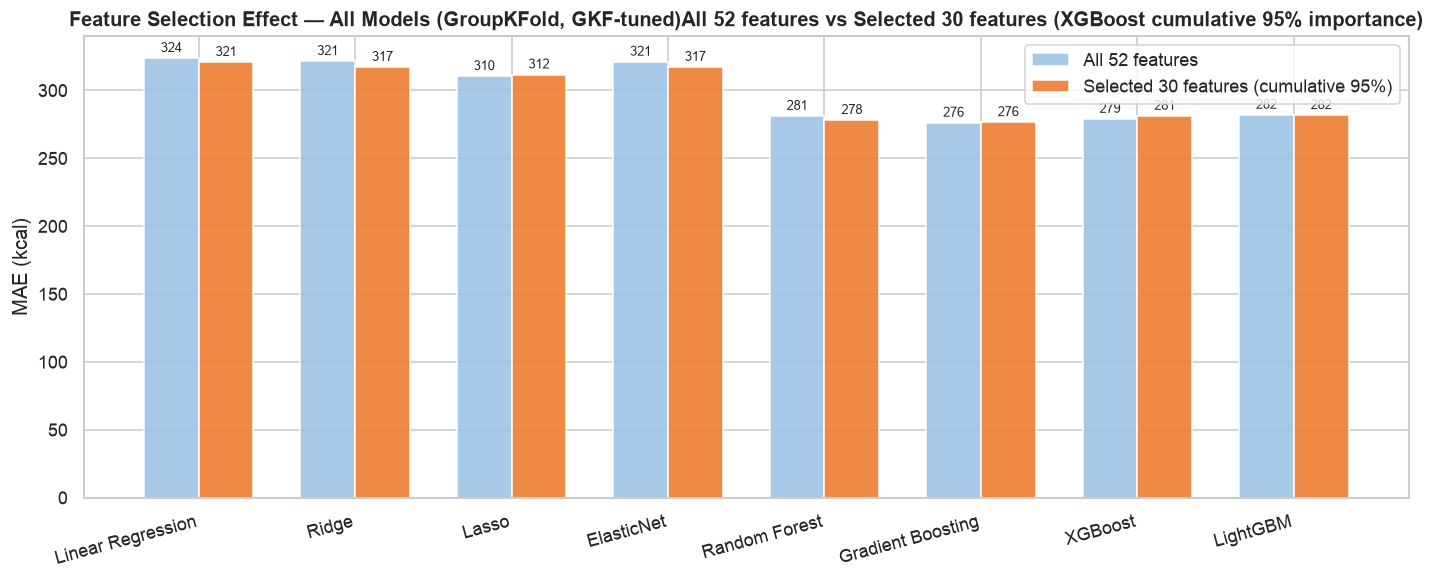

In [21]:
# ── Feature Selection applied to ALL models (using XGBoost-derived selected_features) ──
# selected_features computed above via cumulative 95% importance from XGBoost GKF-tuned

print(f"Selected features: {len(selected_features)} / {len(feature_cols)}")
print(f"Dropped: {len(dropped_features)} features")
print()

X_sel = df[["id"] + selected_features]

fs_rows = []
print(f"{"Model":<22} {"All-feat MAE":>14} {"Sel-feat MAE":>14} {"Diff":>8}")
print("-" * 62)

for name in default_models:
    # --- All features ---
    pipe_all = make_pipe(get_gkf_tuned_model(name))
    cv_all = cross_validate(pipe_all, X, y, cv=gkf, groups=groups, n_jobs=2,
                            scoring={"mae": "neg_mean_absolute_error"})
    mae_all = -cv_all["test_mae"].mean()

    # --- Selected features ---
    pipe_sel = Pipeline([
        ("imputer", PerUserMedianImputer(feature_cols=selected_features)),
        ("scaler",  StandardScaler()),
        ("model",   get_gkf_tuned_model(name)),
    ])
    cv_sel = cross_validate(pipe_sel, X_sel, y, cv=gkf, groups=groups, n_jobs=2,
                            scoring={"mae": "neg_mean_absolute_error"})
    mae_sel = -cv_sel["test_mae"].mean()
    diff    = mae_sel - mae_all

    fs_rows.append({"Model": name, "All features": mae_all,
                    "Selected features": mae_sel, "Diff": diff})
    marker = " <-- better" if diff < -1 else (" <-- worse" if diff > 1 else "")
    print(f"{name:<22} {mae_all:>14.1f} {mae_sel:>14.1f} {diff:>+8.1f}{marker}")

fs_df = pd.DataFrame(fs_rows).set_index("Model")

# ── Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(fs_df))
w = 0.35
b1 = ax.bar(x - w/2, fs_df["All features"],      w, label=f"All {len(feature_cols)} features", color="#9DC3E6", alpha=0.9)
b2 = ax.bar(x + w/2, fs_df["Selected features"], w, label=f"Selected {len(selected_features)} features (cumulative 95%)", color="#ED7D31", alpha=0.9)
ax.bar_label(b1, fmt="%.0f", padding=2, fontsize=8)
ax.bar_label(b2, fmt="%.0f", padding=2, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(fs_df.index, rotation=15, ha="right")
ax.set_ylabel("MAE (kcal)")
ax.set_title(f"Feature Selection Effect — All Models (GroupKFold, GKF-tuned)"
             f"All {len(feature_cols)} features vs Selected {len(selected_features)} features (XGBoost cumulative 95% importance)",
             fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


## 9b. Feature Importance — All 7 Models Compared

Extract normalized importance from all 7 GKF-tuned models and rank features side-by-side.
- **Tree models** (RF, GB, XGBoost, LightGBM): `feature_importances_` (gain-based)
- **Linear models** (Linear Regression, Ridge, Lasso): `abs(coef_)` (absolute coefficient)

In [ ]:
# ── Extract normalized feature importance from all 7 GKF-tuned models ────────────
import joblib, os
import sys, os as _os
sys.path.insert(0, _os.path.abspath(".."))
from lifesnaps_lib.preprocessing import PerUserMedianImputer  # needed for joblib.load
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
import lightgbm as lgb

MODELS_DIR = '../saved_models'
model_file_map = {
    'Linear Regression': 'linear_regression_gkf_tuned.joblib',
    'Ridge':             'ridge_gkf_tuned.joblib',
    'Lasso':             'lasso_gkf_tuned.joblib',
    'ElasticNet':        'elasticnet_gkf_tuned.joblib',
    'Random Forest':     'random_forest_gkf_tuned.joblib',
    'Gradient Boosting': 'gradient_boosting_gkf_tuned.joblib',
    'XGBoost':           'xgboost_gkf_tuned.joblib',
    'LightGBM':          'lightgbm_gkf_tuned.joblib',
}

try:
    pipes = tuned_pipes_gkf
    need_fit = True
    print("Using tuned_pipes_gkf from session")
except NameError:
    pipes = {}
    for name, fname in model_file_map.items():
        fpath = os.path.join(MODELS_DIR, fname)
        if os.path.exists(fpath):
            pipes[name] = joblib.load(fpath)
    need_fit = False
    print(f"Loaded {len(pipes)} models from saved_models/ (already fitted, skipping fit)")

importance_dict = {}
for name, pipe in pipes.items():
    if need_fit:
        pipe.fit(X, y)
    model = pipe.named_steps["model"]

    if hasattr(model, "feature_importances_"):
        scores = model.feature_importances_
    elif hasattr(model, "coef_"):
        scores = np.abs(model.coef_)
    else:
        continue

    total = scores.sum()
    scores = scores / total if total > 0 else scores
    importance_dict[name] = pd.Series(scores, index=feature_cols)

importance_df = pd.DataFrame(importance_dict)
importance_df["mean"] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values("mean", ascending=False)

print("\n=== Feature Importance (normalized, all models) ===")
print(importance_df.round(4).to_string())


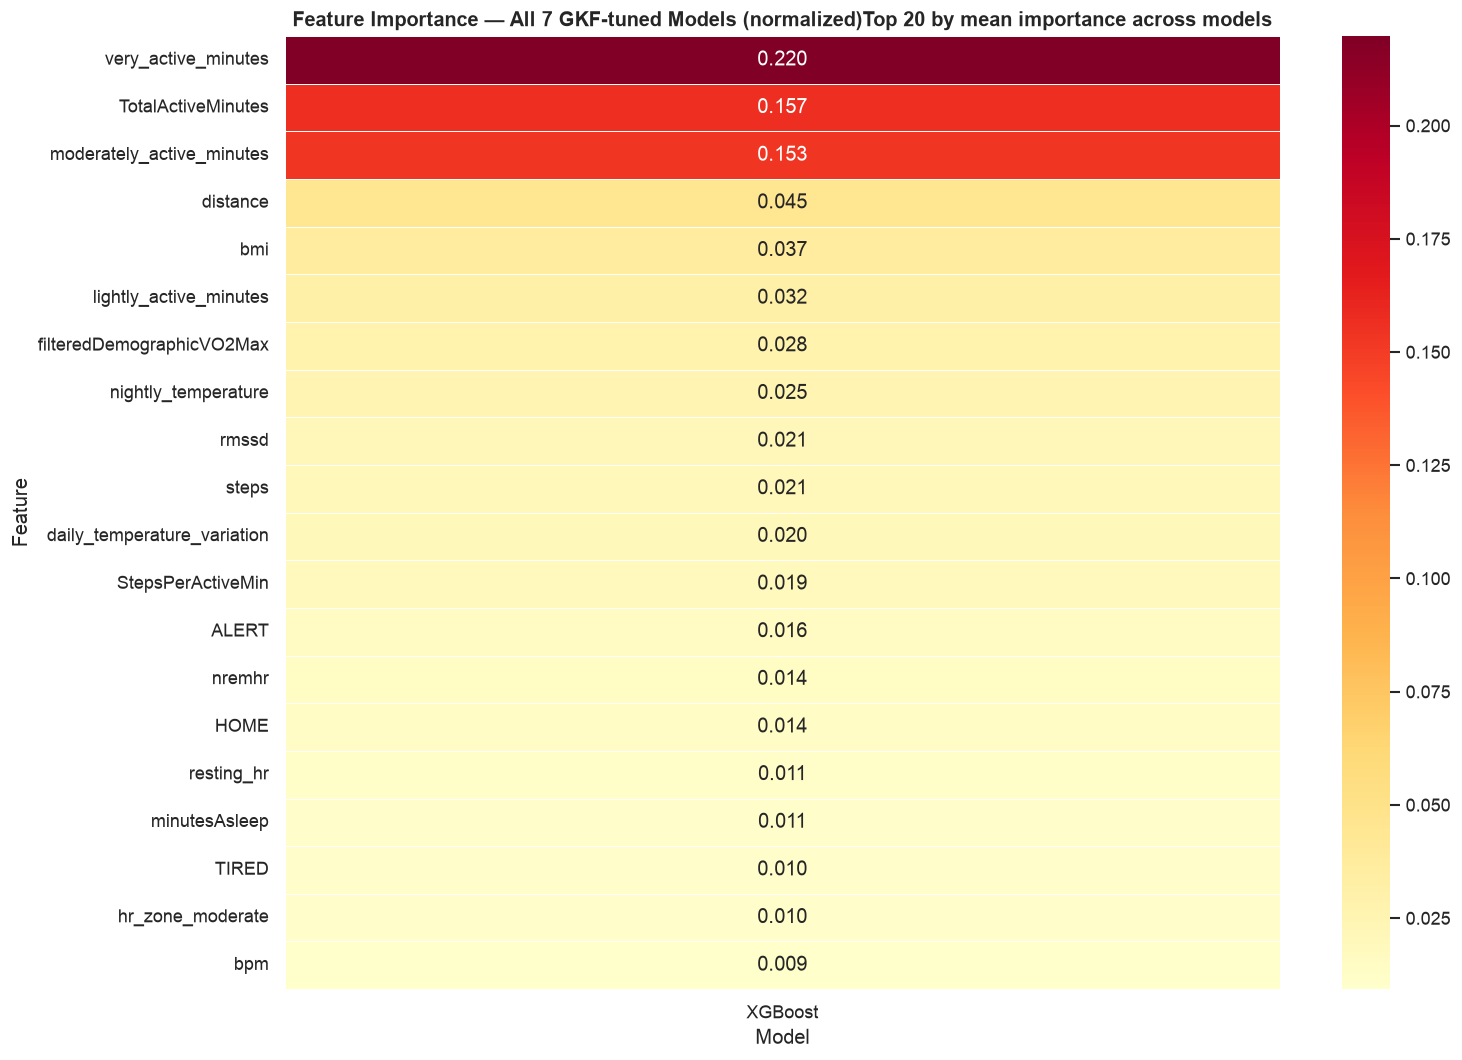

In [ ]:
# ── Heatmap: top 20 features across all 7 models ────────────────────────────────
top20 = importance_df.head(20).drop(columns="mean")

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(
    top20,
    cmap="YlOrRd",
    annot=True,
    fmt=".3f",
    linewidths=0.4,
    ax=ax
)
ax.set_title(
    "Feature Importance — All 7 GKF-tuned Models (normalized)"
    "Top 20 by mean importance across models",
    fontweight="bold", fontsize=12
)
ax.set_xlabel("Model")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()


=== Feature Rank per Model (1 = most important) — Top 20 ===
                             XGBoost  mean_rank
very_active_minutes                1        1.0
TotalActiveMinutes                 2        2.0
moderately_active_minutes          3        3.0
distance                           4        4.0
bmi                                5        5.0
lightly_active_minutes             6        6.0
filteredDemographicVO2Max          7        7.0
nightly_temperature                8        8.0
rmssd                              9        9.0
steps                             10       10.0
daily_temperature_variation       11       11.0
StepsPerActiveMin                 12       12.0
ALERT                             13       13.0
nremhr                            14       14.0
HOME                              15       15.0
resting_hr                        16       16.0
minutesAsleep                     17       17.0
TIRED                             18       18.0
hr_zone_moderate           

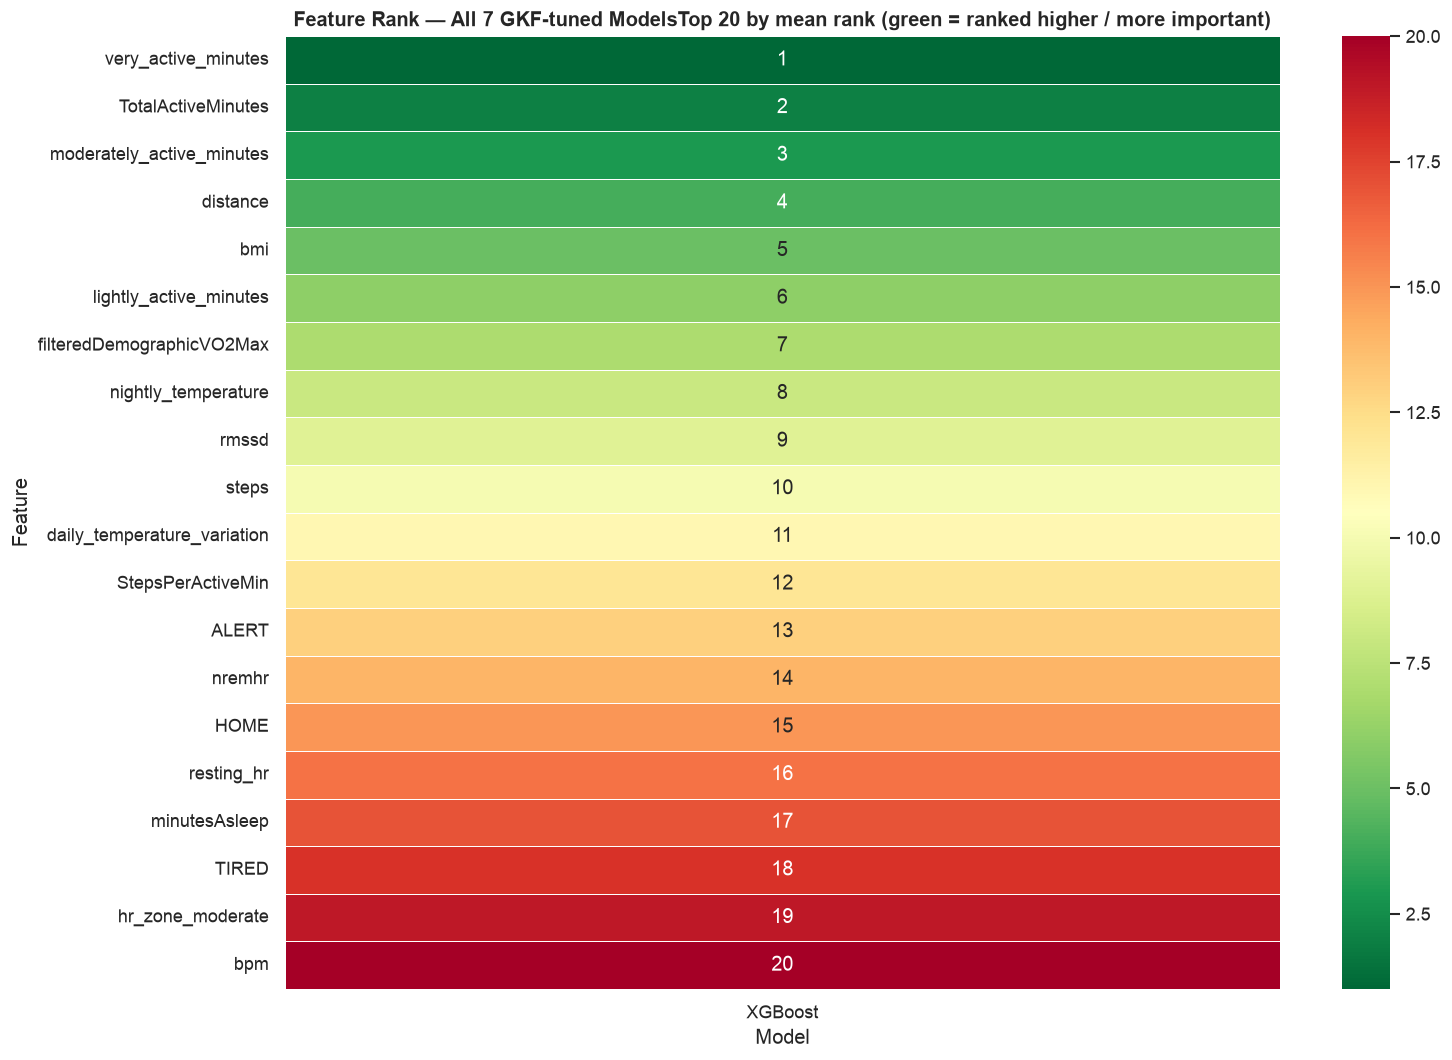

In [ ]:
# ── Rank table: position each model assigns to each feature ─────────────────────
rank_df = importance_df.drop(columns="mean").rank(ascending=False).astype(int)
rank_df["mean_rank"] = importance_df.drop(columns="mean").rank(ascending=False).mean(axis=1).round(1)
rank_df = rank_df.sort_values("mean_rank")

print("=== Feature Rank per Model (1 = most important) — Top 20 ===")
print(rank_df.head(20).to_string())

# ── Rank heatmap (top 20) ────────────────────────────────────────────────────────
rank_top20 = rank_df.head(20).drop(columns="mean_rank")

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(
    rank_top20,
    cmap="RdYlGn_r",   # low rank (important) = green
    annot=True,
    fmt="d",
    linewidths=0.4,
    ax=ax
)
ax.set_title(
    "Feature Rank — All 7 GKF-tuned Models"
    "Top 20 by mean rank (green = ranked higher / more important)",
    fontweight="bold", fontsize=12
)
ax.set_xlabel("Model")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()


## 10. Visual Comparison — All Models & CV Methods

                              KFold MAE  KFold R2  GKF MAE  GKF R2
Model                                                             
Linear Regression (default)       252.1       0.7    323.7     0.5
Ridge (default)                   252.2       0.7    324.5     0.6
Lasso (default)                   253.0       0.7    323.2     0.6
Random Forest (default)           109.4       0.9    288.5     0.6
Gradient Boosting (default)       155.4       0.9    281.5     0.6
XGBoost (default)                 108.6       0.9    291.3     0.6
LightGBM (default)                105.7       0.9    290.8     0.6
XGBoost KFold-tuned (52f)          92.9       0.9    284.1     0.6
XGBoost GKF-tuned (52f)           116.4       0.9    278.9     0.6
XGBoost GKF-tuned (19f) BEST      114.8       0.9    281.2     0.6


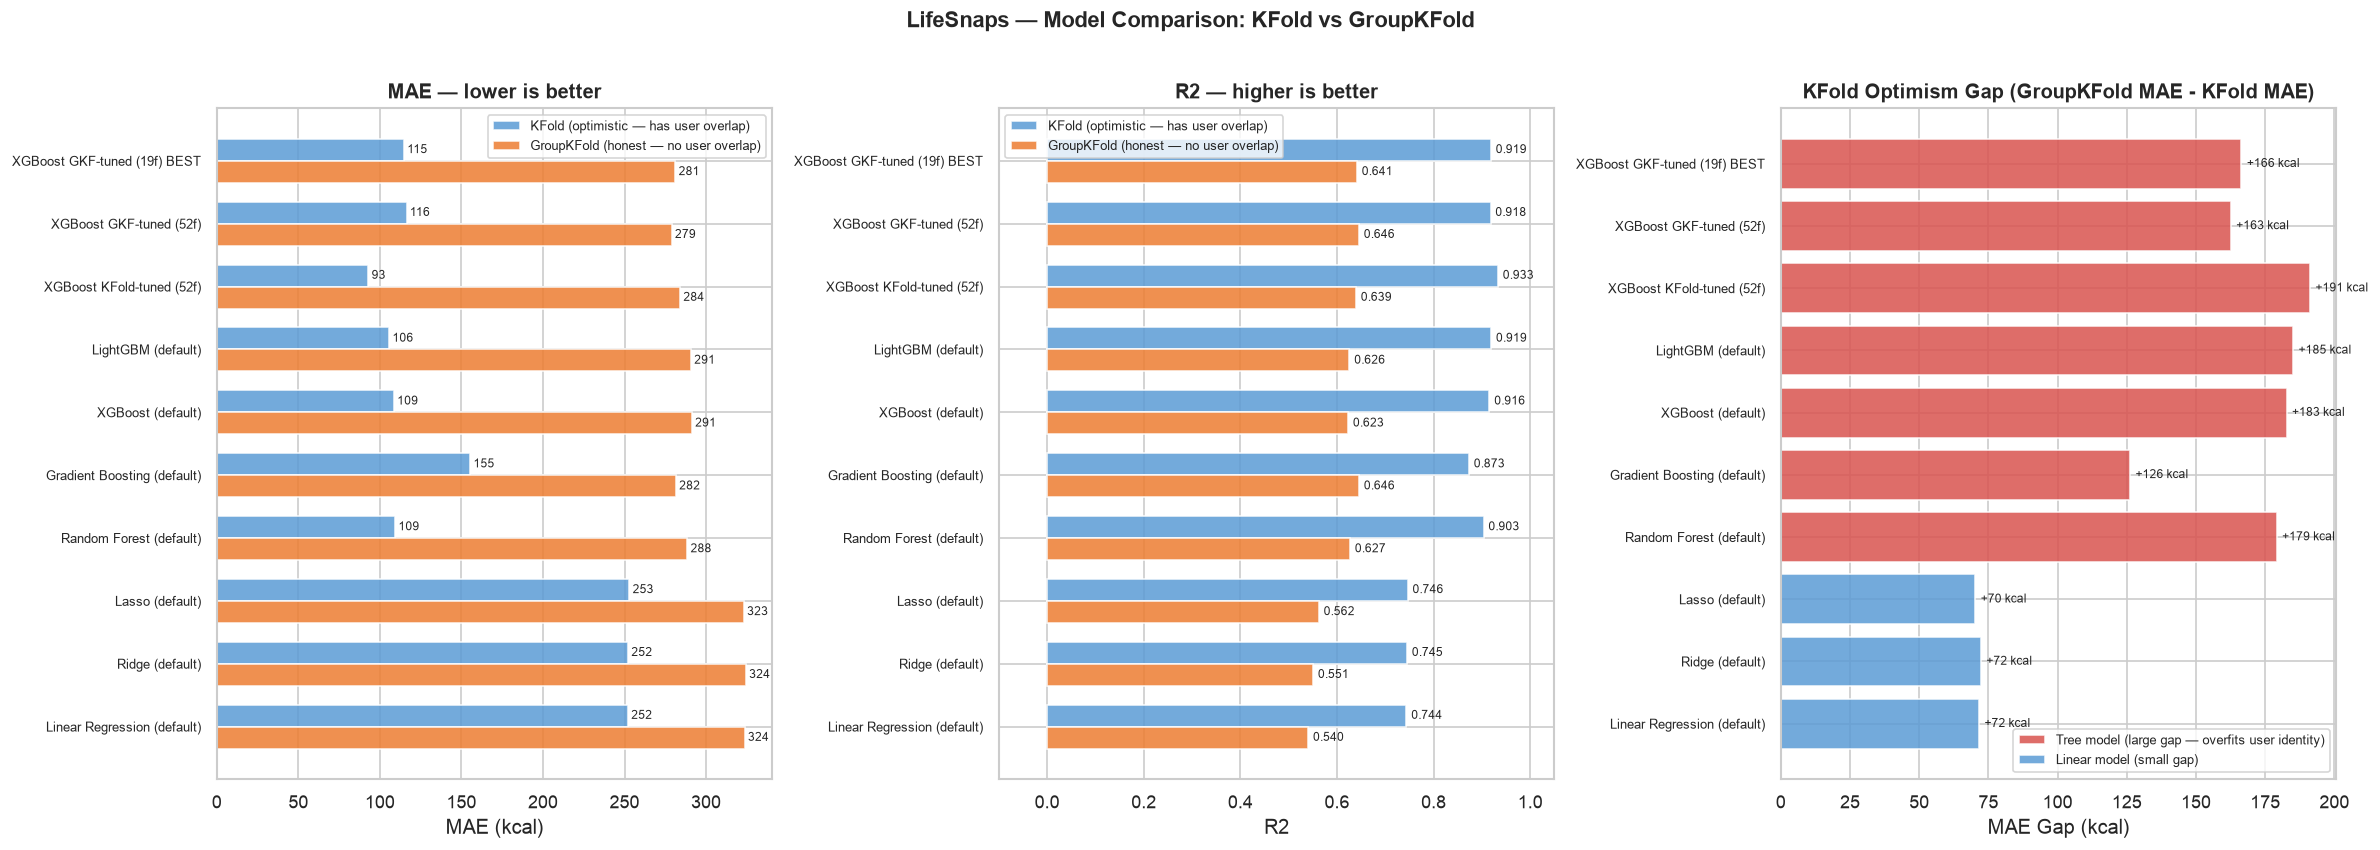

In [ ]:
# Collect all results for comparison
def eval_both(pipe, X_input, label):
    scoring = {"mae": "neg_mean_absolute_error", "r2": "r2"}
    kf_res  = cross_validate(pipe, X_input, y, cv=kf,  scoring=scoring, n_jobs=2)
    gkf_res = cross_validate(pipe, X_input, y, cv=gkf, groups=groups, scoring=scoring, n_jobs=2)
    return {"Model": label,
            "KFold MAE": -kf_res["test_mae"].mean(),  "KFold R2": kf_res["test_r2"].mean(),
            "GKF MAE":  -gkf_res["test_mae"].mean(),  "GKF R2":  gkf_res["test_r2"].mean()}

rows = []
for name in ["Linear Regression", "Ridge", "Lasso", "Random Forest", "Gradient Boosting", "XGBoost", "LightGBM"]:
    pipe_b = Pipeline([
        ("imputer", PerUserMedianImputer(feature_cols=feature_cols)),
        ("scaler",  StandardScaler()),
        ("model",   base_models[name]),
    ])
    rows.append(eval_both(pipe_b, X, name + " (default)"))

rows.append(eval_both(pipe_kfold_tuned, X,     "XGBoost KFold-tuned (52f)"))
rows.append(eval_both(pipe_gkf_tuned,   X,     "XGBoost GKF-tuned (52f)"))
rows.append(eval_both(pipe_sel,         X_sel, "XGBoost GKF-tuned (19f) BEST"))

cmp = pd.DataFrame(rows).set_index("Model")
print(cmp.round(1).to_string())

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

models = cmp.index.tolist()
x = np.arange(len(models))
width = 0.35

# --- MAE ---
ax = axes[0]
b1 = ax.barh(x + width/2, cmp["KFold MAE"], width, label="KFold (optimistic — has user overlap)", color="#5B9BD5", alpha=0.85)
b2 = ax.barh(x - width/2, cmp["GKF MAE"],   width, label="GroupKFold (honest — no user overlap)", color="#ED7D31", alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(models, fontsize=8)
ax.set_xlabel("MAE (kcal)")
ax.set_title("MAE — lower is better", fontweight="bold")
ax.legend(fontsize=8)
for bar in b1: ax.text(bar.get_width()+2, bar.get_y()+bar.get_height()/2, f"{bar.get_width():.0f}", va="center", fontsize=7)
for bar in b2: ax.text(bar.get_width()+2, bar.get_y()+bar.get_height()/2, f"{bar.get_width():.0f}", va="center", fontsize=7)

# --- R2 ---
ax = axes[1]
b1 = ax.barh(x + width/2, cmp["KFold R2"], width, label="KFold (optimistic — has user overlap)", color="#5B9BD5", alpha=0.85)
b2 = ax.barh(x - width/2, cmp["GKF R2"],   width, label="GroupKFold (honest — no user overlap)", color="#ED7D31", alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(models, fontsize=8)
ax.set_xlabel("R2")
ax.set_title("R2 — higher is better", fontweight="bold")
ax.set_xlim(-0.1, 1.05)
ax.legend(fontsize=8)
for bar in b1: ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2, f"{bar.get_width():.3f}", va="center", fontsize=7)
for bar in b2: ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2, f"{bar.get_width():.3f}", va="center", fontsize=7)

# --- Optimism Gap ---
ax = axes[2]
gap = cmp["GKF MAE"] - cmp["KFold MAE"]
# 2 colors only: tree models (large gap) vs linear models (small gap)
is_tree = ["Linear" not in m and "Ridge" not in m and "Lasso" not in m for m in models]
colors_gap = ["#D9534F" if t else "#5B9BD5" for t in is_tree]
bars = ax.barh(x, gap, color=colors_gap, alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(models, fontsize=8)
ax.set_xlabel("MAE Gap (kcal)")
ax.set_title("KFold Optimism Gap (GroupKFold MAE - KFold MAE)", fontweight="bold")
ax.axvline(0, color="black", linewidth=0.5)
for bar, v in zip(bars, gap):
    ax.text(v+2, bar.get_y()+bar.get_height()/2, f"+{v:.0f} kcal", va="center", fontsize=7)

# Legend for gap chart
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#D9534F", alpha=0.85, label="Tree model (large gap — overfits user identity)"),
    Patch(facecolor="#5B9BD5", alpha=0.85, label="Linear model (small gap)"),
]
ax.legend(handles=legend_elements, fontsize=8, loc="lower right")

plt.suptitle("LifeSnaps — Model Comparison: KFold vs GroupKFold", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 11. Tune ALL Models with Optuna (GroupKFold)

> Tune every model using the same honest GroupKFold CV so we can fairly compare before vs after tuning.

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

gkf = GroupKFold(n_splits=3)
N_TRIALS = 20

def run_study(objective_fn, name):
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective_fn, n_trials=N_TRIALS, n_jobs=1, show_progress_bar=False)
    print(f"{name:<25} best MAE={-study.best_value:.1f}")
    return study

def gkf_score(pipe, X_input=X, scoring="neg_mean_absolute_error"):
    return cross_val_score(pipe, X_input, y, cv=gkf, groups=groups,
                           scoring=scoring, n_jobs=2).mean()

# ── Ridge ──────────────────────────────────────────────────────────────────
def obj_ridge(trial):
    alpha = trial.suggest_float("alpha", 1e-3, 1e3, log=True)
    pipe = Pipeline([("imputer", PerUserMedianImputer(feature_cols=feature_cols)),
                     ("scaler",  StandardScaler()),
                     ("model",   Ridge(alpha=alpha))])
    return gkf_score(pipe)

# ── Lasso ──────────────────────────────────────────────────────────────────
def obj_lasso(trial):
    alpha = trial.suggest_float("alpha", 1e-3, 1e2, log=True)
    pipe = Pipeline([("imputer", PerUserMedianImputer(feature_cols=feature_cols)),
                     ("scaler",  StandardScaler()),
                     ("model",   Lasso(alpha=alpha, max_iter=5000))])
    return gkf_score(pipe)

# ── Random Forest ──────────────────────────────────────────────────────────
def obj_rf(trial):
    params = dict(
        n_estimators    = trial.suggest_int("n_estimators", 50, 400),
        max_depth       = trial.suggest_int("max_depth", 3, 20),
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20),
        min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 10),
        max_features    = trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.8]),
    )
    pipe = Pipeline([("imputer", PerUserMedianImputer(feature_cols=feature_cols)),
                     ("scaler",  StandardScaler()),
                     ("model",   RandomForestRegressor(**params, random_state=42, n_jobs=-1))])
    return gkf_score(pipe)

# ── Gradient Boosting ──────────────────────────────────────────────────────
def obj_gb(trial):
    params = dict(
        n_estimators  = trial.suggest_int("n_estimators", 50, 500),
        max_depth     = trial.suggest_int("max_depth", 2, 6),
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample     = trial.suggest_float("subsample", 0.5, 1.0),
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20),
    )
    pipe = Pipeline([("imputer", PerUserMedianImputer(feature_cols=feature_cols)),
                     ("scaler",  StandardScaler()),
                     ("model",   GradientBoostingRegressor(**params, random_state=42))])
    return gkf_score(pipe)

# ── XGBoost ────────────────────────────────────────────────────────────────
def obj_xgb(trial):
    params = dict(
        n_estimators     = trial.suggest_int("n_estimators", 50, 500),
        max_depth        = trial.suggest_int("max_depth", 2, 8),
        learning_rate    = trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample        = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0),
        min_child_weight = trial.suggest_int("min_child_weight", 1, 10),
        reg_alpha        = trial.suggest_float("reg_alpha", 0.0, 5.0),
        reg_lambda       = trial.suggest_float("reg_lambda", 1.0, 10.0),
    )
    pipe = Pipeline([("imputer", PerUserMedianImputer(feature_cols=feature_cols)),
                     ("scaler",  StandardScaler()),
                     ("model",   XGBRegressor(**params, random_state=42, verbosity=0, n_jobs=2))])
    return gkf_score(pipe)

# ── LightGBM ───────────────────────────────────────────────────────────────
def obj_lgbm(trial):
    params = dict(
        n_estimators     = trial.suggest_int("n_estimators", 50, 500),
        max_depth        = trial.suggest_int("max_depth", 2, 8),
        learning_rate    = trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample        = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0),
        min_child_samples = trial.suggest_int("min_child_samples", 5, 50),
        reg_alpha        = trial.suggest_float("reg_alpha", 0.0, 5.0),
        reg_lambda       = trial.suggest_float("reg_lambda", 1.0, 10.0),
    )
    pipe = Pipeline([("imputer", PerUserMedianImputer(feature_cols=feature_cols)),
                     ("scaler",  StandardScaler()),
                     ("model",   lgb.LGBMRegressor(**params, random_state=42, verbose=-1, n_jobs=2))])
    return gkf_score(pipe)

print(f"Tuning all models ({N_TRIALS} Optuna trials each, GroupKFold)...")
study_ridge = run_study(obj_ridge, "Ridge")
study_lasso = run_study(obj_lasso, "Lasso")
study_rf    = run_study(obj_rf,    "Random Forest")
study_gb    = run_study(obj_gb,    "Gradient Boosting")
study_xgb   = run_study(obj_xgb,  "XGBoost")
study_lgbm  = run_study(obj_lgbm, "LightGBM")
print("Done!")

Tuning all models (20 Optuna trials each, GroupKFold)...
Ridge                     best MAE=321.5
Lasso                     best MAE=310.4
Random Forest             best MAE=281.1
Gradient Boosting         best MAE=276.1
XGBoost                   best MAE=278.9
LightGBM                  best MAE=281.9
Done!


## 12. Before vs After Tuning — Full Comparison

In [ ]:
def eval_gkf(pipe, X_input=X):
    cv  = cross_validate(pipe, X_input, y, cv=gkf, groups=groups, n_jobs=2, scoring={
        "mae": "neg_mean_absolute_error", "rmse": "neg_mean_squared_error", "r2": "r2"})
    return -cv["test_mae"].mean(), np.sqrt(-cv["test_rmse"].mean()), cv["test_r2"].mean()

def make_pipe(model):
    return Pipeline([("imputer", PerUserMedianImputer(feature_cols=feature_cols)),
                     ("scaler",  StandardScaler()),
                     ("model",   model)])

# ── Default (before tuning) ────────────────────────────────────────────────
defaults = {
    "Linear Regression": LinearRegression(),
    "Ridge":             Ridge(alpha=1.0),
    "Lasso":             Lasso(alpha=1.0),
    "Random Forest":     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost":           XGBRegressor(n_estimators=100, random_state=42, verbosity=0, n_jobs=2),
    "LightGBM":          lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1, n_jobs=2),
}

# ── Tuned (after tuning) ───────────────────────────────────────────────────
tuned = {
    "Linear Regression": LinearRegression(),   # no hyperparams
    "Ridge":             Ridge(**study_ridge.best_params),
    "Lasso":             Lasso(**{k: v for k, v in study_lasso.best_params.items()}, max_iter=5000),
    "Random Forest":     RandomForestRegressor(**study_rf.best_params, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(**study_gb.best_params, random_state=42),
    "XGBoost":           XGBRegressor(**study_xgb.best_params, random_state=42, verbosity=0, n_jobs=2),
    "LightGBM":          lgb.LGBMRegressor(**study_lgbm.best_params, random_state=42, verbose=-1, n_jobs=2),
}

rows = []
for name in defaults:
    mae_b, rmse_b, r2_b = eval_gkf(make_pipe(defaults[name]))
    mae_t, rmse_t, r2_t = eval_gkf(make_pipe(tuned[name]))
    rows.append({"Model": name,
                 "MAE_before": mae_b,  "MAE_after": mae_t,
                 "RMSE_before": rmse_b, "RMSE_after": rmse_t,
                 "R2_before": r2_b,   "R2_after": r2_t})
    print(f"{name:<22} MAE {mae_b:.1f}→{mae_t:.1f}  RMSE {rmse_b:.1f}→{rmse_t:.1f}  R² {r2_b:.3f}→{r2_t:.3f}")

cmp_all = pd.DataFrame(rows).set_index("Model")


Linear Regression      MAE 323.7→323.7  RMSE 474.5→474.5  R² 0.540→0.540
Ridge                  MAE 324.5→321.5  RMSE 469.1→440.2  R² 0.551→0.599
Lasso                  MAE 323.2→310.4  RMSE 462.7→423.3  R² 0.562→0.631
Random Forest          MAE 288.5→281.1  RMSE 426.3→411.0  R² 0.627→0.655
Gradient Boosting      MAE 281.5→276.1  RMSE 416.1→410.1  R² 0.646→0.656
XGBoost                MAE 291.3→278.9  RMSE 429.9→417.2  R² 0.623→0.646
LightGBM               MAE 290.8→281.9  RMSE 427.1→412.6  R² 0.626→0.653


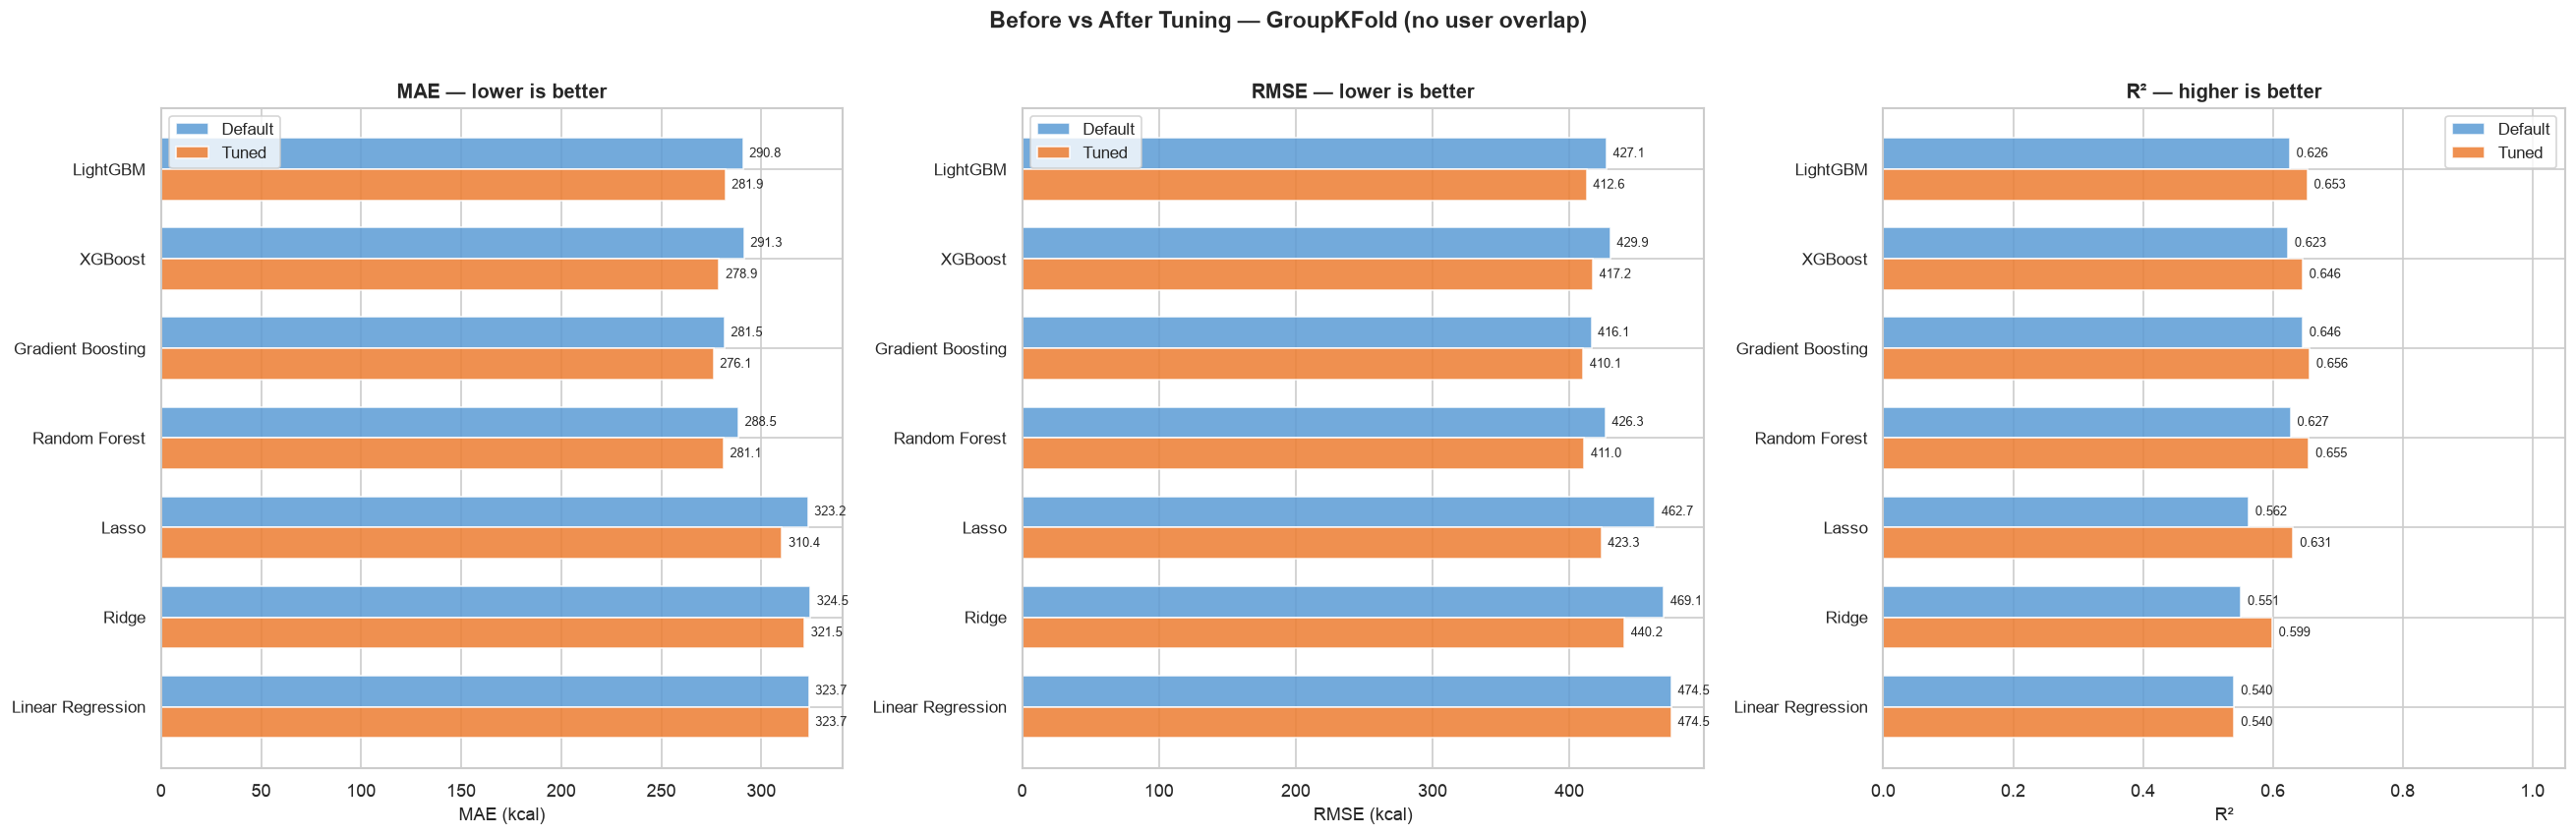

=== Improvement from Tuning (GroupKFold MAE) ===
                   MAE_before  MAE_after  MAE_improvement  MAE_improvement_%
Model                                                                       
Linear Regression       323.7      323.7              0.0                0.0
Ridge                   324.5      321.5              3.0                0.9
Lasso                   323.2      310.4             12.9                4.0
Random Forest           288.5      281.1              7.4                2.6
Gradient Boosting       281.5      276.1              5.5                1.9
XGBoost                 291.3      278.9             12.4                4.3
LightGBM                290.8      281.9              8.8                3.0


In [ ]:
# ── Plot: Before vs After for MAE, RMSE, R² ──────────────────────────────
model_names = cmp_all.index.tolist()
x = np.arange(len(model_names))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle("Before vs After Tuning — GroupKFold (no user overlap)",
             fontsize=14, fontweight="bold", y=1.01)

metric_cfg = [
    ("MAE",  "MAE_before",  "MAE_after",  "MAE (kcal)",  True,  (0, None)),
    ("RMSE", "RMSE_before", "RMSE_after", "RMSE (kcal)", True,  (0, None)),
    ("R²",   "R2_before",   "R2_after",   "R²",          False, (0, 1.05)),
]

for ax, (title, col_b, col_a, xlabel, lower_better, ylim) in zip(axes, metric_cfg):
    bars_b = ax.barh(x + width/2, cmp_all[col_b], width,
                     label="Default", color="#5B9BD5", alpha=0.85)
    bars_a = ax.barh(x - width/2, cmp_all[col_a], width,
                     label="Tuned",   color="#ED7D31", alpha=0.85)
    ax.set_yticks(x)
    ax.set_yticklabels(model_names, fontsize=10)
    ax.set_xlabel(xlabel, fontsize=11)
    direction = "lower is better" if lower_better else "higher is better"
    ax.set_title(f"{title} — {direction}", fontweight="bold", fontsize=12)
    ax.set_xlim(ylim)
    ax.legend(fontsize=10)
    # Value labels
    for bar in bars_b:
        v = bar.get_width()
        ax.text(v + (ylim[1] or cmp_all[col_b].max()) * 0.01,
                bar.get_y() + bar.get_height()/2,
                f"{v:.1f}" if title != "R²" else f"{v:.3f}",
                va="center", fontsize=8)
    for bar in bars_a:
        v = bar.get_width()
        ax.text(v + (ylim[1] or cmp_all[col_b].max()) * 0.01,
                bar.get_y() + bar.get_height()/2,
                f"{v:.1f}" if title != "R²" else f"{v:.3f}",
                va="center", fontsize=8)

plt.tight_layout()
plt.show()

# ── Improvement summary ───────────────────────────────────────────────────
print("=== Improvement from Tuning (GroupKFold MAE) ===")
cmp_all["MAE_improvement"] = cmp_all["MAE_before"] - cmp_all["MAE_after"]
cmp_all["MAE_improvement_%"] = (cmp_all["MAE_improvement"] / cmp_all["MAE_before"] * 100).round(1)
print(cmp_all[["MAE_before","MAE_after","MAE_improvement","MAE_improvement_%"]].round(1).to_string())


=== Final Tuned Models — Ranked by MAE (GroupKFold) ===
                       MAE     RMSE     R2
Model                                     
Gradient Boosting  276.079  410.147  0.656
XGBoost            278.937  417.175  0.646
Random Forest      281.094  410.953  0.655
LightGBM           281.920  412.576  0.653
Lasso              310.362  423.332  0.631
Ridge              321.493  440.188  0.599
Linear Regression  323.723  474.540  0.540


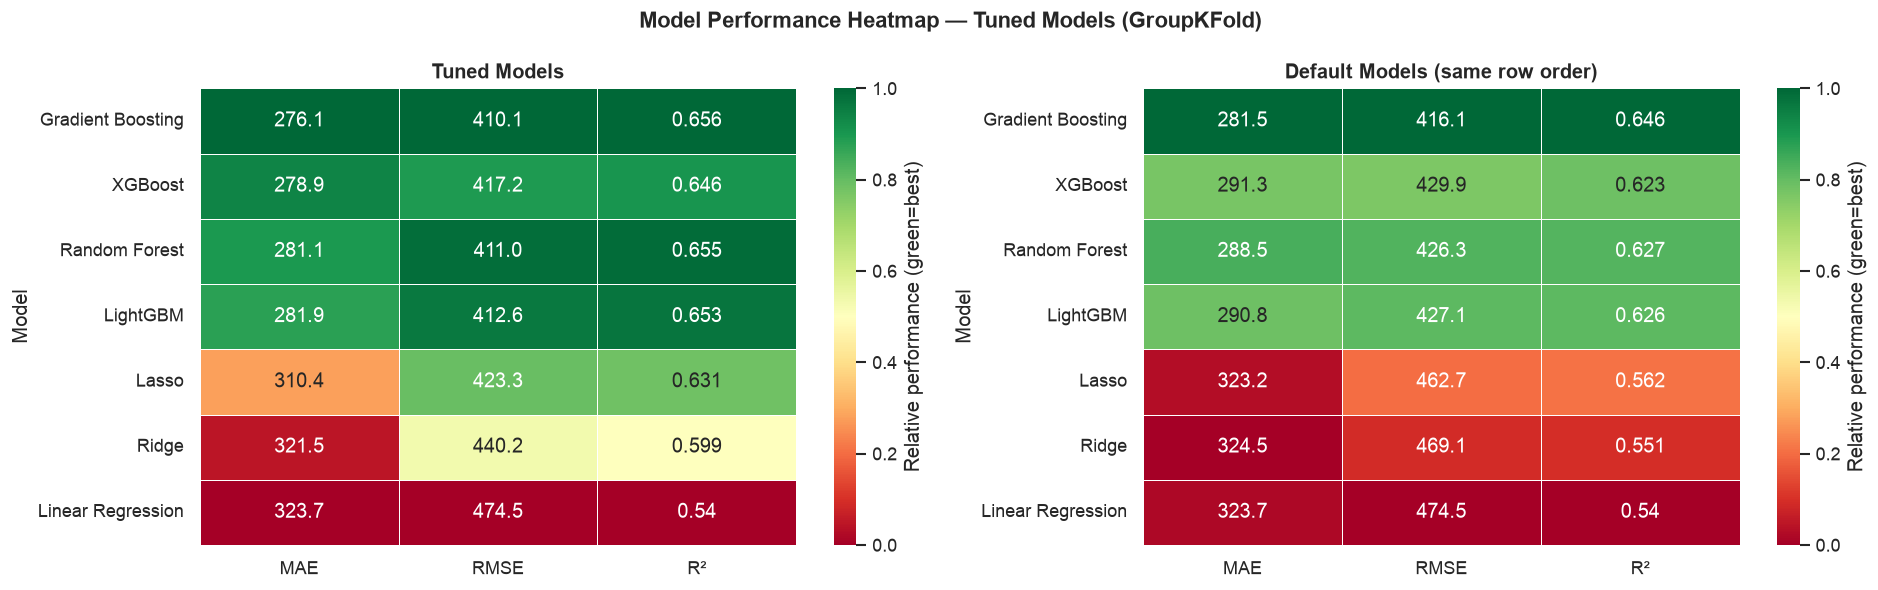

In [46]:
# ── Ranked final tuned model comparison (all metrics) ────────────────────
print("=== Final Tuned Models — Ranked by MAE (GroupKFold) ===")
ranked = cmp_all[["MAE_after", "RMSE_after", "R2_after"]].copy()
ranked.columns = ["MAE", "RMSE", "R2"]
ranked = ranked.sort_values("MAE")
print(ranked.round(3).to_string())

# ── Heatmap of all metrics ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Model Performance Heatmap — Tuned Models (GroupKFold)",
             fontsize=13, fontweight="bold")

# Normalize each metric for coloring (0=worst, 1=best)
def normalize_col(s, lower_better=True):
    mn, mx = s.min(), s.max()
    if mx == mn: return pd.Series([0.5]*len(s), index=s.index)
    normed = (s - mn) / (mx - mn)
    return 1 - normed if lower_better else normed

heatmap_data = pd.DataFrame({
    "MAE":  normalize_col(ranked["MAE"],  lower_better=True),
    "RMSE": normalize_col(ranked["RMSE"], lower_better=True),
    "R²":   normalize_col(ranked["R2"],   lower_better=False),
})
annot_data = pd.DataFrame({
    "MAE":  ranked["MAE"].round(1).astype(str),
    "RMSE": ranked["RMSE"].round(1).astype(str),
    "R²":   ranked["R2"].round(3).astype(str),
})

sns.heatmap(heatmap_data, annot=annot_data, fmt="", cmap="RdYlGn",
            vmin=0, vmax=1, ax=axes[0], linewidths=0.5,
            cbar_kws={"label": "Relative performance (green=best)"})
axes[0].set_title("Tuned Models", fontweight="bold")
axes[0].set_xlabel("")

# Before tuning heatmap
before_data_raw = cmp_all[["MAE_before","RMSE_before","R2_before"]].copy()
before_data_raw.columns = ["MAE","RMSE","R2"]
before_data_raw = before_data_raw.loc[ranked.index]   # same row order
heatmap_before = pd.DataFrame({
    "MAE":  normalize_col(before_data_raw["MAE"],  lower_better=True),
    "RMSE": normalize_col(before_data_raw["RMSE"], lower_better=True),
    "R²":   normalize_col(before_data_raw["R2"],   lower_better=False),
})
annot_before = pd.DataFrame({
    "MAE":  before_data_raw["MAE"].round(1).astype(str),
    "RMSE": before_data_raw["RMSE"].round(1).astype(str),
    "R²":   before_data_raw["R2"].round(3).astype(str),
})
sns.heatmap(heatmap_before, annot=annot_before, fmt="", cmap="RdYlGn",
            vmin=0, vmax=1, ax=axes[1], linewidths=0.5,
            cbar_kws={"label": "Relative performance (green=best)"})
axes[1].set_title("Default Models (same row order)", fontweight="bold")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()


## 13. TimeSeriesSplit — Predict Future of Known User

> 🟢 **Evaluation: TimeSeriesSplit (3 splits, sorted by date)**  
> Train on past → test on future. No temporal leakage. User overlap allowed.  
> Goal: *given this user's history → predict their future calories*

| CV Method | Temporal leakage | User overlap | เหมาะกับ |
|---|---|---|---|
| KFold | ⚠️ Yes | ⚠️ Yes | baseline เปรียบเทียบ |
| GroupKFold | ⚠️ Yes | ✅ No | predict user ใหม่ |
| **TimeSeriesSplit** | ✅ No | ⚠️ Yes | predict อนาคต user เดิม |

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

# Sort by date — required for TimeSeriesSplit
df_sorted     = df.sort_values(['date']).reset_index(drop=True)
X_sorted      = df_sorted[['id'] + feature_cols]
y_sorted      = df_sorted[target]
groups_sorted = df_sorted['id']

tscv = TimeSeriesSplit(n_splits=3)

print(f'Data sorted by date: {df_sorted["date"].min().date()} → {df_sorted["date"].max().date()}')
print(f'Rows: {len(df_sorted)} | Users: {df_sorted["id"].nunique()}')

# Show fold sizes
for fold, (tr, te) in enumerate(tscv.split(X_sorted), 1):
    print(f'  Fold {fold}: train={len(tr):,}  test={len(te):,}  '
          f'test dates: {df_sorted["date"].iloc[te[0]].date()} → {df_sorted["date"].iloc[te[-1]].date()}')

Data sorted by date: 2021-05-24 → 2022-01-21
Rows: 6638 | Users: 71
  Fold 1: train=1,661  test=1,659  test dates: 2021-07-04 → 2021-09-01
  Fold 2: train=3,320  test=1,659  test dates: 2021-09-01 → 2021-12-02
  Fold 3: train=4,979  test=1,659  test dates: 2021-12-02 → 2022-01-21


In [ ]:
def tscv_eval(pipe, X_input=X_sorted, label=''):
    cv = cross_validate(pipe, X_input, y_sorted, cv=tscv, n_jobs=2, scoring={
        'mae': 'neg_mean_absolute_error', 'rmse': 'neg_mean_squared_error', 'r2': 'r2'})
    mae  = -cv['test_mae'].mean()
    rmse = np.sqrt(-cv['test_rmse'].mean())
    r2   = cv['test_r2'].mean()
    if label:
        print(f'{label:<40} MAE={mae:.1f}  RMSE={rmse:.1f}  R²={r2:.3f}')
    return mae, rmse, r2

print('TimeSeriesSplit evaluation — Default models:')
print('-' * 70)
tscv_default = {}
for name, model in default_models.items():
    pipe = make_pipe(model)
    tscv_default[name] = tscv_eval(pipe, label=f'{name} (default)')

print('\nTimeSeriesSplit evaluation — GKF-tuned models:')
print('-' * 70)
tscv_gkf_tuned = {}
for name in default_models:
    pipe = make_pipe(get_gkf_tuned_model(name))
    tscv_gkf_tuned[name] = tscv_eval(pipe, label=f'{name} (GKF-tuned)')

TimeSeriesSplit evaluation — Default models:
----------------------------------------------------------------------
Linear Regression (default)              MAE=307.8  RMSE=399.4  R²=0.641
Ridge (default)                          MAE=306.1  RMSE=397.1  R²=0.645
Lasso (default)                          MAE=303.3  RMSE=393.6  R²=0.651
Random Forest (default)                  MAE=183.3  RMSE=311.5  R²=0.782
Gradient Boosting (default)              MAE=201.3  RMSE=315.4  R²=0.777
XGBoost (default)                        MAE=180.9  RMSE=309.5  R²=0.785
LightGBM (default)                       MAE=177.5  RMSE=305.3  R²=0.791

TimeSeriesSplit evaluation — GKF-tuned models:
----------------------------------------------------------------------
Linear Regression (GKF-tuned)            MAE=307.8  RMSE=399.4  R²=0.641
Ridge (GKF-tuned)                        MAE=316.7  RMSE=397.4  R²=0.643
Lasso (GKF-tuned)                        MAE=306.6  RMSE=387.3  R²=0.661
Random Forest (GKF-tuned)          

In [ ]:
def make_obj_tscv(model_fn):
    def objective(trial):
        pipe = Pipeline([
            ('imputer', PerUserMedianImputer(feature_cols=feature_cols)),
            ('scaler',  StandardScaler()),
            ('model',   model_fn(trial)),
        ])
        return cross_val_score(pipe, X_sorted, y_sorted, cv=tscv,
                               scoring='neg_mean_absolute_error', n_jobs=2).mean()
    return objective

studies_tscv = {}
print(f'Retuning all models ({N_TRIALS} trials each, TimeSeriesSplit)...')
for name, fn in model_fns.items():
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(make_obj_tscv(fn), n_trials=N_TRIALS, n_jobs=1, show_progress_bar=False)
    studies_tscv[name] = study
    print(f'  {name:<22} GKF-tuned MAE={tscv_gkf_tuned[name][0]:.1f}  '
          f'TSCV-tuned MAE={-study.best_value:.1f}  '
          f'Δ={tscv_gkf_tuned[name][0] - (-study.best_value):+.1f}')
studies_tscv['Linear Regression'] = None
print('Done!')

Retuning all models (20 trials each, TimeSeriesSplit)...
  Ridge                  GKF-tuned MAE=316.7  TSCV-tuned MAE=305.1  Δ=+11.6
  Lasso                  GKF-tuned MAE=306.6  TSCV-tuned MAE=303.2  Δ=+3.4
  Random Forest          GKF-tuned MAE=197.9  TSCV-tuned MAE=188.7  Δ=+9.2
  Gradient Boosting      GKF-tuned MAE=210.4  TSCV-tuned MAE=163.9  Δ=+46.5
  XGBoost                GKF-tuned MAE=187.5  TSCV-tuned MAE=174.4  Δ=+13.1
  LightGBM               GKF-tuned MAE=193.0  TSCV-tuned MAE=171.4  Δ=+21.6
Done!


=== 3-Way CV Comparison (tuned models) ===
                   KFold MAE  GKF MAE (tuned)  TSCV MAE (tuned)
Model                                                          
Linear Regression      252.1            323.7             307.8
Ridge                  252.2            321.5             305.1
Lasso                  253.0            310.4             303.2
Random Forest          109.4            281.1             188.7
Gradient Boosting      155.4            276.1             163.9
XGBoost                108.6            278.9             174.4
LightGBM               105.7            281.9             171.4

KFold  → leaky, optimistic
GKF    → honest for NEW user
TSCV   → honest for SAME user future prediction


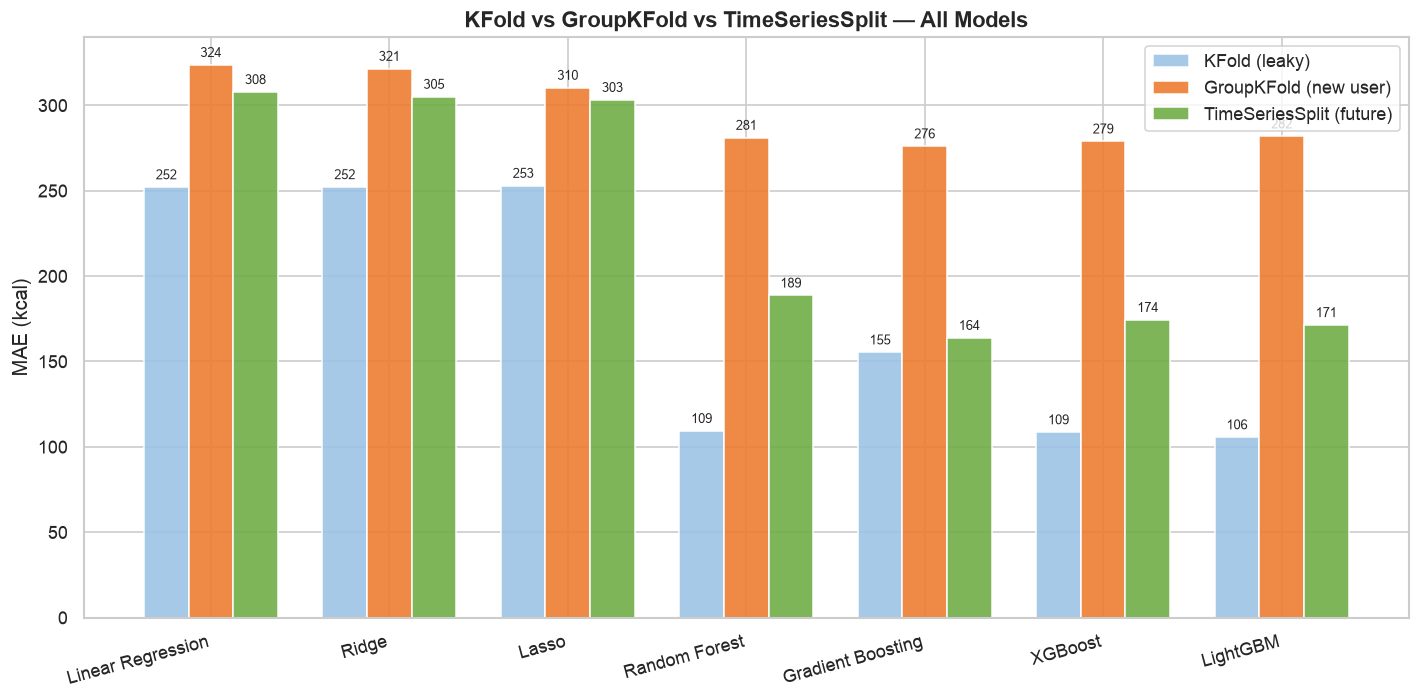

In [ ]:
def get_tscv_tuned_model(name):
    study = studies_tscv[name]
    if name == 'Linear Regression' or study is None:
        return LinearRegression()
    p = study.best_params
    if name == 'Ridge':             return Ridge(alpha=p['alpha'])
    if name == 'Lasso':             return Lasso(alpha=p['alpha'], max_iter=5000)
    if name == 'ElasticNet':        return ElasticNet(alpha=p['alpha'], l1_ratio=p['l1_ratio'], max_iter=5000)
    if name == 'Random Forest':     return RandomForestRegressor(**p, random_state=42, n_jobs=-1)
    if name == 'Gradient Boosting': return GradientBoostingRegressor(**p, random_state=42)
    if name == 'XGBoost':           return XGBRegressor(**p, random_state=42, verbosity=0, n_jobs=2)
    if name == 'LightGBM':          return lgb.LGBMRegressor(**p, random_state=42, verbose=-1, n_jobs=2)

rows = []
for name in default_models:
    tscv_mae = -cross_val_score(
        make_pipe(get_tscv_tuned_model(name)), X_sorted, y_sorted,
        cv=tscv, scoring='neg_mean_absolute_error', n_jobs=2).mean()
    rows.append({
        'Model':            name,
        'KFold MAE':        results[name]['MAE'],
        'GKF MAE (tuned)':  summary_df.loc[name, 'GKF MAE (GKF-tuned)'],
        'TSCV MAE (tuned)': tscv_mae,
    })

cmp_tscv = pd.DataFrame(rows).set_index('Model')
print('=== 3-Way CV Comparison (tuned models) ===')
print(cmp_tscv.round(1).to_string())
print()
print('KFold  → leaky, optimistic')
print('GKF    → honest for NEW user')
print('TSCV   → honest for SAME user future prediction')

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(cmp_tscv))
width = 0.25

b1 = ax.bar(x - width, cmp_tscv['KFold MAE'],        width, label='KFold (leaky)',          color='#9DC3E6', alpha=0.9)
b2 = ax.bar(x,          cmp_tscv['GKF MAE (tuned)'],  width, label='GroupKFold (new user)',   color='#ED7D31', alpha=0.9)
b3 = ax.bar(x + width,  cmp_tscv['TSCV MAE (tuned)'], width, label='TimeSeriesSplit (future)',color='#70AD47', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(cmp_tscv.index, rotation=15, ha='right')
ax.set_ylabel('MAE (kcal)')
ax.set_title('KFold vs GroupKFold vs TimeSeriesSplit — All Models', fontweight='bold', fontsize=13)
ax.legend()
ax.bar_label(b1, fmt='%.0f', padding=3, fontsize=8)
ax.bar_label(b2, fmt='%.0f', padding=3, fontsize=8)
ax.bar_label(b3, fmt='%.0f', padding=3, fontsize=8)
plt.tight_layout()
plt.show()

## 14. Within-User Prediction

> 🟣 **Evaluation: Per-user TimeSeriesSplit**  
> For each user: train on their early days → test on their later days.  
> Model trained on ALL users' train data, tested only on each user's held-out future.  
> Goal: *how well can we predict a known user's future calories?*

| CV Method | Temporal leakage | User overlap | เหมาะกับ |
|---|---|---|---|
| KFold | ⚠️ Yes | ⚠️ Yes | baseline |
| GroupKFold | ⚠️ Yes | ✅ No | predict user ใหม่ |
| TimeSeriesSplit | ✅ No | ⚠️ Yes | predict อนาคต (mixed users) |
| **Within-User** | ✅ No | ✅ No | predict อนาคต user เดิม (strictest) |

In [ ]:
# ── Within-user split: for each user, last 20% of days = test ────────────
df_sorted2 = df.sort_values(['id', 'date']).reset_index(drop=True)

train_idx_wu, test_idx_wu = [], []
for uid, grp in df_sorted2.groupby('id'):
    n      = len(grp)
    n_test = max(1, int(n * 0.2))
    train_idx_wu.extend(grp.index[:-n_test].tolist())
    test_idx_wu.extend(grp.index[-n_test:].tolist())

X_wu = df_sorted2[['id'] + feature_cols]
y_wu = df_sorted2[target]

print(f'Within-user split:')
print(f'  Train: {len(train_idx_wu):,} rows ({len(train_idx_wu)/len(df_sorted2)*100:.0f}%)')
print(f'  Test:  {len(test_idx_wu):,} rows  ({len(test_idx_wu)/len(df_sorted2)*100:.0f}%)')
print(f'  Every user has future test days held out')

X_train_wu = X_wu.iloc[train_idx_wu]
X_test_wu  = X_wu.iloc[test_idx_wu]
y_train_wu = y_wu.iloc[train_idx_wu]
y_test_wu  = y_wu.iloc[test_idx_wu]

Within-user split:
  Train: 5,342 rows (80%)
  Test:  1,296 rows  (20%)
  Every user has future test days held out


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def wu_eval(model_obj, label):
    pipe = make_pipe(model_obj)
    pipe.fit(X_train_wu, y_train_wu)
    y_pred = pipe.predict(X_test_wu)
    mae  = mean_absolute_error(y_test_wu, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_wu, y_pred))
    r2   = r2_score(y_test_wu, y_pred)
    print(f'{label:<40} MAE={mae:.1f}  RMSE={rmse:.1f}  R²={r2:.3f}')
    return mae, rmse, r2

print('Within-User evaluation — Default models:')
print('-' * 70)
wu_default = {}
for name, model in default_models.items():
    wu_default[name] = wu_eval(model, f'{name} (default)')

print('\nWithin-User evaluation — GKF-tuned models:')
print('-' * 70)
wu_gkf_tuned = {}
for name in default_models:
    wu_gkf_tuned[name] = wu_eval(get_gkf_tuned_model(name), f'{name} (GKF-tuned)')

Within-User evaluation — Default models:
----------------------------------------------------------------------
Linear Regression (default)              MAE=257.5  RMSE=323.5  R²=0.761
Ridge (default)                          MAE=257.6  RMSE=323.7  R²=0.760
Lasso (default)                          MAE=259.0  RMSE=325.3  R²=0.758
Random Forest (default)                  MAE=115.4  RMSE=234.0  R²=0.875
Gradient Boosting (default)              MAE=164.9  RMSE=256.3  R²=0.850
XGBoost (default)                        MAE=120.4  RMSE=240.5  R²=0.868
LightGBM (default)                       MAE=125.2  RMSE=235.3  R²=0.873

Within-User evaluation — GKF-tuned models:
----------------------------------------------------------------------
Linear Regression (GKF-tuned)            MAE=257.5  RMSE=323.5  R²=0.761
Ridge (GKF-tuned)                        MAE=284.4  RMSE=356.8  R²=0.709
Lasso (GKF-tuned)                        MAE=281.0  RMSE=350.2  R²=0.720
Random Forest (GKF-tuned)                MA

=== 4-Way CV Comparison ===
                   KFold MAE  GKF MAE (tuned)  TSCV MAE (tuned)  Within-User MAE
Model                                                                           
Linear Regression      252.1            323.7             307.8            257.5
Ridge                  252.2            321.5             316.7            284.4
Lasso                  253.0            310.4             306.6            281.0
Random Forest          109.4            281.1             197.9            125.4
Gradient Boosting      155.4            276.1             210.4            179.4
XGBoost                108.6            278.9             187.5            131.0
LightGBM               105.7            281.9             193.0            144.1

KFold       → leaky, optimistic
GKF         → honest for NEW user
TSCV        → honest, mixed users, future dates
Within-User → strictest: same user, future dates only


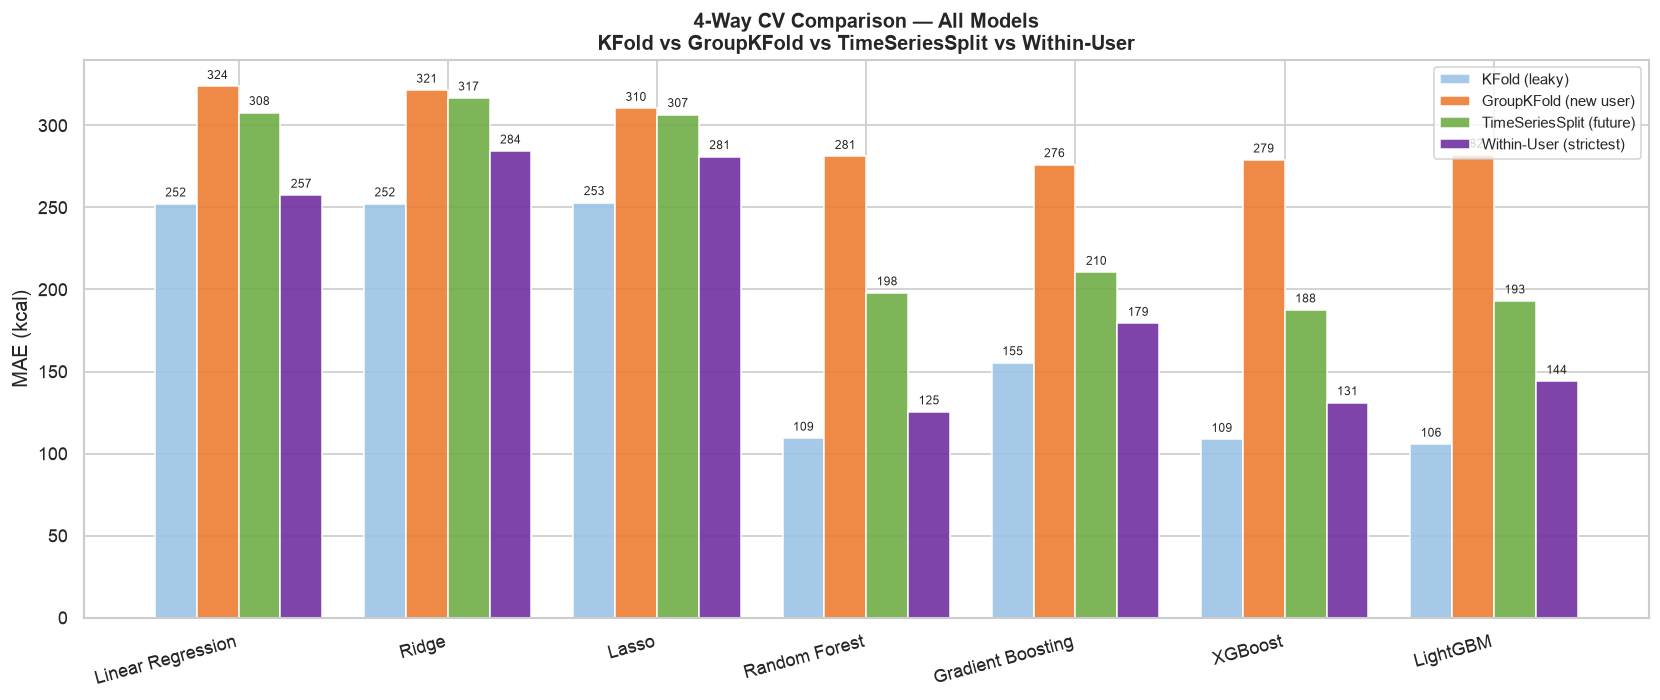

In [ ]:
# ── 4-way comparison: KFold vs GKF vs TSCV vs Within-User ────────────────
rows = []
for name in default_models:
    rows.append({
        'Model':             name,
        'KFold MAE':         results[name]['MAE'],
        'GKF MAE (tuned)':   summary_df.loc[name, 'GKF MAE (GKF-tuned)'],
        'TSCV MAE (tuned)':  tscv_gkf_tuned[name][0],
        'Within-User MAE':   wu_gkf_tuned[name][0],
    })

cmp_wu = pd.DataFrame(rows).set_index('Model')
print('=== 4-Way CV Comparison ===')
print(cmp_wu.round(1).to_string())
print()
print('KFold       → leaky, optimistic')
print('GKF         → honest for NEW user')
print('TSCV        → honest, mixed users, future dates')
print('Within-User → strictest: same user, future dates only')

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
x     = np.arange(len(cmp_wu))
width = 0.2

b1 = ax.bar(x - 1.5*width, cmp_wu['KFold MAE'],        width, label='KFold (leaky)',           color='#9DC3E6', alpha=0.9)
b2 = ax.bar(x - 0.5*width, cmp_wu['GKF MAE (tuned)'],  width, label='GroupKFold (new user)',    color='#ED7D31', alpha=0.9)
b3 = ax.bar(x + 0.5*width, cmp_wu['TSCV MAE (tuned)'], width, label='TimeSeriesSplit (future)', color='#70AD47', alpha=0.9)
b4 = ax.bar(x + 1.5*width, cmp_wu['Within-User MAE'],  width, label='Within-User (strictest)',  color='#7030A0', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(cmp_wu.index, rotation=15, ha='right')
ax.set_ylabel('MAE (kcal)')
ax.set_title('4-Way CV Comparison — All Models\n'
             'KFold vs GroupKFold vs TimeSeriesSplit vs Within-User',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=9)
for bars in [b1, b2, b3, b4]:
    ax.bar_label(bars, fmt='%.0f', padding=3, fontsize=7)
plt.tight_layout()
plt.show()

## 15. Per-User Model — Personalized Prediction

> 🔴 **Evaluation: Per-user train/test split (last 20% = test)**  
> Train a **separate model for each user** using only their own data.  
> Goal: *maximum personalization — does a dedicated model beat a shared one?*

| Approach | Train data | Personalization | Risk |
|---|---|---|---|
| Shared model (Sec 14) | All users | Low | Low |
| **Per-user model** | 1 user only | Maximum | Overfit (few rows) |

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def per_user_eval(model_obj, label=''):
    results_u = []
    for uid, grp in df.sort_values('date').groupby('id'):
        grp    = grp.reset_index(drop=True)
        n      = len(grp)
        n_test = max(1, int(n * 0.2))
        if n - n_test < 10:
            continue
        X_u = grp[['id'] + feature_cols]
        y_u = grp[target]
        X_tr, X_te = X_u.iloc[:-n_test], X_u.iloc[-n_test:]
        y_tr, y_te = y_u.iloc[:-n_test], y_u.iloc[-n_test:]
        pipe_u = make_pipe(model_obj)
        pipe_u.fit(X_tr, y_tr)
        y_pred = pipe_u.predict(X_te)
        results_u.append(mean_absolute_error(y_te, y_pred))
    mae = np.mean(results_u)
    if label:
        print(f'{label:<40} MAE={mae:.1f}  (n_users={len(results_u)})')
    return mae

print('Per-User evaluation — Default models:')
print('-' * 70)
pu_default = {}
for name, model in default_models.items():
    pu_default[name] = per_user_eval(model, f'{name} (default)')

print('\nPer-User evaluation — GKF-tuned models:')
print('-' * 70)
pu_gkf_tuned = {}
for name in default_models:
    pu_gkf_tuned[name] = per_user_eval(get_gkf_tuned_model(name), f'{name} (GKF-tuned)')

Per-User evaluation — Default models:
----------------------------------------------------------------------
Linear Regression (default)              MAE=100.4  (n_users=71)
Ridge (default)                          MAE=81.4  (n_users=71)
Lasso (default)                          MAE=70.3  (n_users=71)
Random Forest (default)                  MAE=110.3  (n_users=71)
Gradient Boosting (default)              MAE=99.8  (n_users=71)
XGBoost (default)                        MAE=106.7  (n_users=71)
LightGBM (default)                       MAE=161.0  (n_users=71)

Per-User evaluation — GKF-tuned models:
----------------------------------------------------------------------
Linear Regression (GKF-tuned)            MAE=100.4  (n_users=71)
Ridge (GKF-tuned)                        MAE=288.2  (n_users=71)
Lasso (GKF-tuned)                        MAE=79.3  (n_users=71)
Random Forest (GKF-tuned)                MAE=136.1  (n_users=71)
Gradient Boosting (GKF-tuned)            MAE=92.9  (n_users=71)
XGBo

=== 5-Way CV Comparison ===
                   KFold MAE  GKF MAE (tuned)  TSCV MAE (tuned)  Within-User MAE  Per-User MAE
Model                                                                                         
Linear Regression      252.1            323.7             307.8            257.5         100.4
Ridge                  252.2            321.5             316.7            284.4         288.2
Lasso                  253.0            310.4             306.6            281.0          79.3
Random Forest          109.4            281.1             197.9            125.4         136.1
Gradient Boosting      155.4            276.1             210.4            179.4          92.9
XGBoost                108.6            278.9             187.5            131.0         121.2
LightGBM               105.7            281.9             193.0            144.1         210.9

KFold       → leaky, optimistic
GKF         → honest for NEW user
TSCV        → honest, mixed users, future dates
Wi

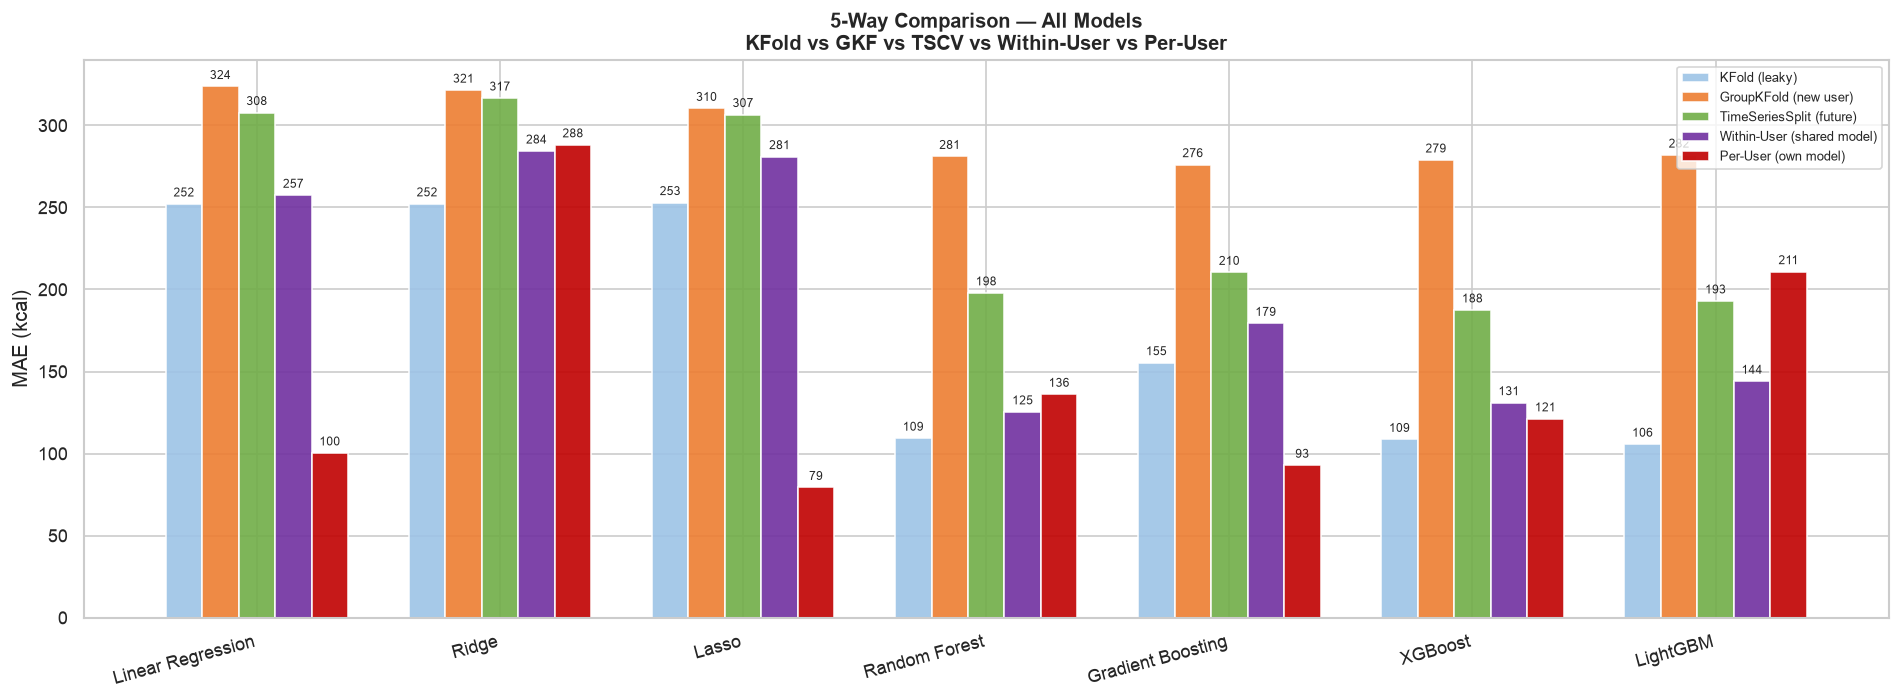

In [ ]:
# ── 5-way comparison: KFold vs GKF vs TSCV vs Within-User vs Per-User ────
rows = []
for name in default_models:
    rows.append({
        'Model':              name,
        'KFold MAE':          results[name]['MAE'],
        'GKF MAE (tuned)':    summary_df.loc[name, 'GKF MAE (GKF-tuned)'],
        'TSCV MAE (tuned)':   tscv_gkf_tuned[name][0],
        'Within-User MAE':    wu_gkf_tuned[name][0],
        'Per-User MAE':       pu_gkf_tuned[name],
    })

cmp_pu = pd.DataFrame(rows).set_index('Model')
print('=== 5-Way CV Comparison ===')
print(cmp_pu.round(1).to_string())
print()
print('KFold       → leaky, optimistic')
print('GKF         → honest for NEW user')
print('TSCV        → honest, mixed users, future dates')
print('Within-User → same user, future dates (shared model)')
print('Per-User    → same user, future dates (own model per user)')

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
x     = np.arange(len(cmp_pu))
width = 0.15

b1 = ax.bar(x - 2*width, cmp_pu['KFold MAE'],       width, label='KFold (leaky)',            color='#9DC3E6', alpha=0.9)
b2 = ax.bar(x - 1*width, cmp_pu['GKF MAE (tuned)'], width, label='GroupKFold (new user)',     color='#ED7D31', alpha=0.9)
b3 = ax.bar(x,           cmp_pu['TSCV MAE (tuned)'],width, label='TimeSeriesSplit (future)',  color='#70AD47', alpha=0.9)
b4 = ax.bar(x + 1*width, cmp_pu['Within-User MAE'], width, label='Within-User (shared model)',color='#7030A0', alpha=0.9)
b5 = ax.bar(x + 2*width, cmp_pu['Per-User MAE'],    width, label='Per-User (own model)',      color='#C00000', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(cmp_pu.index, rotation=15, ha='right')
ax.set_ylabel('MAE (kcal)')
ax.set_title('5-Way Comparison — All Models\n'
             'KFold vs GKF vs TSCV vs Within-User vs Per-User',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=8)
for bars in [b1, b2, b3, b4, b5]:
    ax.bar_label(bars, fmt='%.0f', padding=3, fontsize=7)
plt.tight_layout()
plt.show()

## 16. Within-User & Per-User — TimeSeriesSplit CV (ปรับปรุงจาก single split)

> ใช้ **TimeSeriesSplit ต่อ user** แทน single 80/20 split เพื่อลด variance และให้ผลที่น่าเชื่อถือกว่า  
> แต่ละ user จะถูก evaluate หลาย fold โดยเรียงตามวันที่ (temporal order)


In [ ]:
from sklearn.model_selection import TimeSeriesSplit

N_SPLITS  = 3
MIN_TRAIN = 15
MIN_TEST  = 5
tscv_user = TimeSeriesSplit(n_splits=N_SPLITS)

# ─────────────────────────────────────────────────────────────────
# A) Within-User + TimeSeriesSplit CV  (retrain per fold — no leakage)
# ─────────────────────────────────────────────────────────────────
def wu_tscv_eval(model_obj, label=''):
    """Retrain model on each temporal fold's training set → no leakage."""
    df_sorted_wu = df.sort_values('date').reset_index(drop=True)
    X_all = df_sorted_wu[['id'] + feature_cols]
    y_all = df_sorted_wu[target]

    fold_maes, fold_rmses = [], []
    for tr_idx, te_idx in tscv_user.split(df_sorted_wu):
        if len(tr_idx) < MIN_TRAIN or len(te_idx) < MIN_TEST:
            continue
        pipe = make_pipe(model_obj)
        pipe.fit(X_all.iloc[tr_idx], y_all.iloc[tr_idx])
        y_pred = pipe.predict(X_all.iloc[te_idx])
        fold_maes.append(mean_absolute_error(y_all.iloc[te_idx], y_pred))
        fold_rmses.append(np.sqrt(mean_squared_error(y_all.iloc[te_idx], y_pred)))

    mae  = np.mean(fold_maes)
    rmse = np.mean(fold_rmses)
    print(f'{label:<45} MAE={mae:.1f}  RMSE={rmse:.1f}  (folds={len(fold_maes)})')
    return mae, rmse

print('=== Within-User + TimeSeriesSplit CV (retrain per fold) ===')
wu_tscv = {}
for name, model in default_models.items():
    wu_tscv[name] = wu_tscv_eval(model, label=name)

print()

# ─────────────────────────────────────────────────────────────────
# B) Per-User + TimeSeriesSplit CV  (separate model per user)
# ─────────────────────────────────────────────────────────────────
def per_user_tscv_eval(model_obj, label=''):
    fold_maes, fold_rmses = [], []
    skipped_users = 0

    for uid, grp in df.sort_values('date').groupby('id'):
        grp = grp.reset_index(drop=True)
        X_u = grp[['id'] + feature_cols]
        y_u = grp[target]

        user_folds = 0
        for tr_idx, te_idx in tscv_user.split(grp):
            if len(tr_idx) < MIN_TRAIN or len(te_idx) < MIN_TEST:
                continue
            pipe_u = make_pipe(model_obj)
            pipe_u.fit(X_u.iloc[tr_idx], y_u.iloc[tr_idx])
            y_pred = pipe_u.predict(X_u.iloc[te_idx])
            fold_maes.append(mean_absolute_error(y_u.iloc[te_idx], y_pred))
            fold_rmses.append(np.sqrt(mean_squared_error(y_u.iloc[te_idx], y_pred)))
            user_folds += 1

        if user_folds == 0:
            skipped_users += 1

    mae  = np.mean(fold_maes)
    rmse = np.mean(fold_rmses)
    print(f'{label:<45} MAE={mae:.1f}  RMSE={rmse:.1f}  (folds={len(fold_maes)}, skipped_users={skipped_users})')
    return mae, rmse

print('=== Per-User + TimeSeriesSplit CV (separate model per user) ===')
pu_tscv = {}
for name, model in default_models.items():
    pu_tscv[name] = per_user_tscv_eval(model, label=name)

print()

# ─────────────────────────────────────────────────────────────────
# C) เปรียบเทียบ single split vs TimeSeriesSplit CV  (MAE & RMSE เท่านั้น)
# ─────────────────────────────────────────────────────────────────
print('=== MAE Comparison: Single Split vs TimeSeriesSplit CV ===')
print(f'{"Model":<30} {"WU-Single":>10} {"WU-TSCV":>10} {"PU-Single":>10} {"PU-TSCV":>10}')
print('-' * 75)
for name in default_models:
    wu_s  = wu_default[name][0]            if name in wu_default else float('nan')
    wu_cv = wu_tscv[name][0]               if name in wu_tscv    else float('nan')
    pu_s  = pu_default.get(name, float('nan'))
    pu_cv = pu_tscv[name][0]               if name in pu_tscv    else float('nan')
    print(f'{name:<30} {wu_s:>10.1f} {wu_cv:>10.1f} {pu_s:>10.1f} {pu_cv:>10.1f}')


=== Within-User + TimeSeriesSplit CV (retrain per fold) ===
Linear Regression                             MAE=307.8  RMSE=396.9  (folds=3)
Ridge                                         MAE=306.1  RMSE=394.7  (folds=3)
Lasso                                         MAE=303.3  RMSE=391.4  (folds=3)
Random Forest                                 MAE=183.3  RMSE=301.2  (folds=3)
Gradient Boosting                             MAE=201.3  RMSE=303.2  (folds=3)
XGBoost                                       MAE=180.9  RMSE=296.1  (folds=3)
LightGBM                                      MAE=177.5  RMSE=292.6  (folds=3)

=== Per-User + TimeSeriesSplit CV (separate model per user) ===
Linear Regression                             MAE=137.6  RMSE=205.5  (folds=213, skipped_users=0)
Ridge                                         MAE=88.2  RMSE=132.0  (folds=213, skipped_users=0)
Lasso                                         MAE=69.6  RMSE=106.1  (folds=213, skipped_users=0)
Random Forest                 

=== 7-Way Strategy Comparison (MAE) ===
                   KFold  GroupKFold   TSCV  WU-Single  WU-TSCV  PU-Single  PU-TSCV
Model                                                                              
Linear Regression  252.1       323.7  307.8      257.5    307.8      100.4    137.6
Ridge              252.2       321.5  316.7      284.4    306.1      288.2     88.2
Lasso              253.0       310.4  306.6      281.0    303.3       79.3     69.6
Random Forest      109.4       281.1  197.9      125.4    183.3      136.1    119.2
Gradient Boosting  155.4       276.1  210.4      179.4    201.3       92.9    106.0
XGBoost            108.6       278.9  187.5      131.0    180.9      121.2    117.6
LightGBM           105.7       281.9  193.0      144.1    177.5      210.9    260.2

KFold      → leaky, optimistic (users mixed across folds)
GroupKFold → honest for NEW user prediction
TSCV       → honest, future dates, mixed users
WU-Single  → same user, future dates, shared model (si

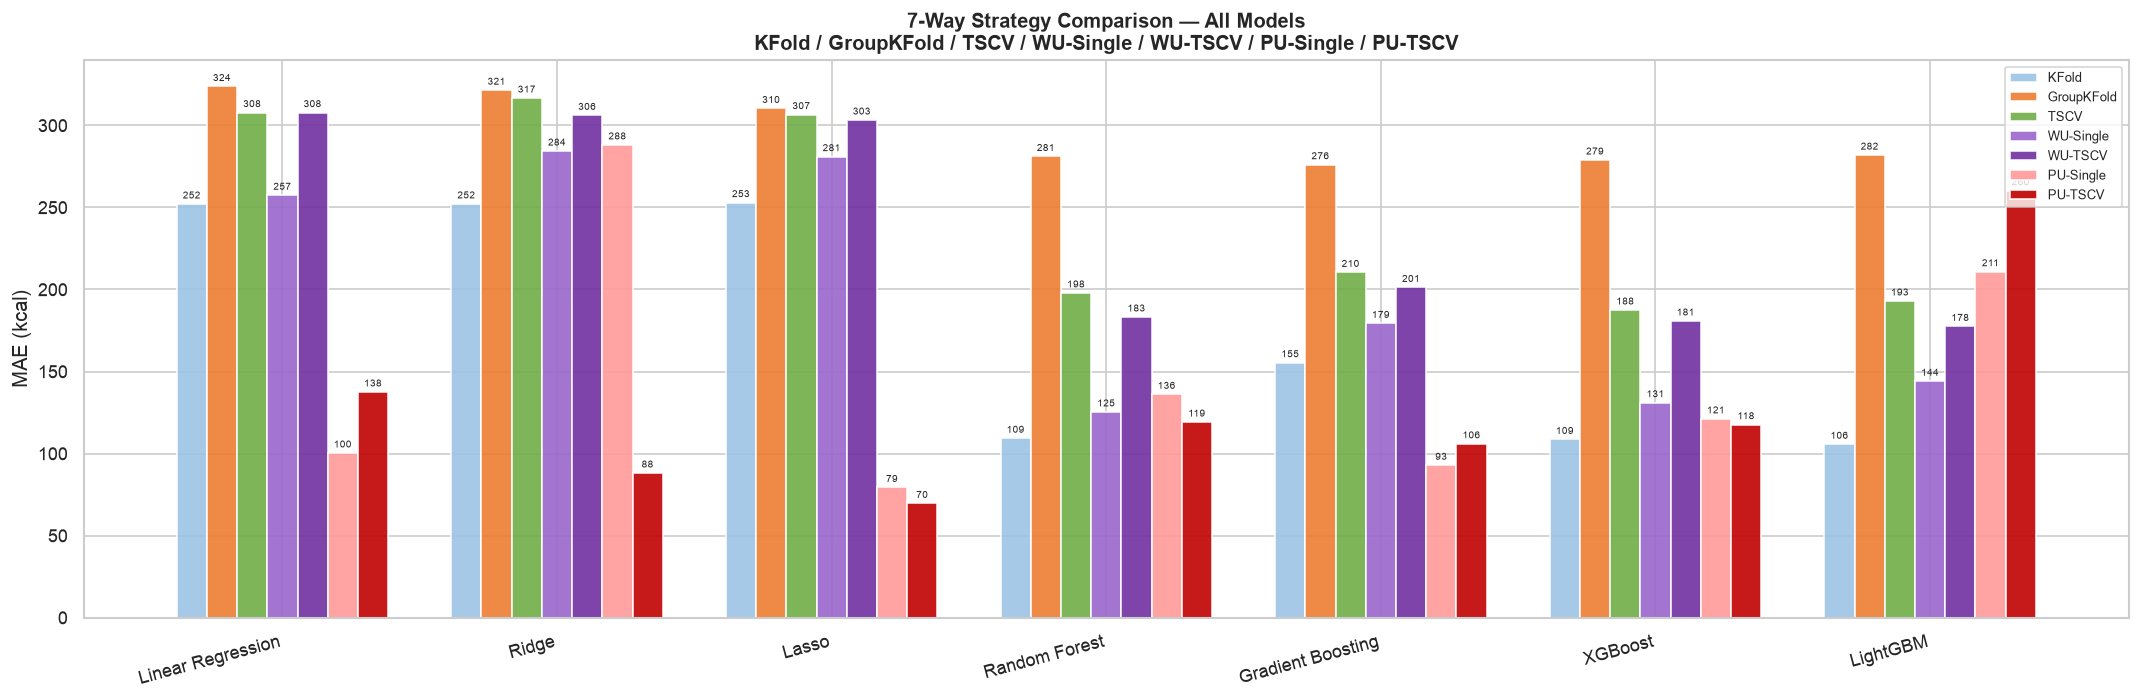

In [ ]:
# ── 7-Way Strategy Comparison — All Strategies รวมกัน ──────────────────────
rows = []
for name in default_models:
    rows.append({
        'Model':          name,
        'KFold':          results[name]['MAE'],
        'GroupKFold':     summary_df.loc[name, 'GKF MAE (GKF-tuned)'],
        'TSCV':           tscv_gkf_tuned[name][0],
        'WU-Single':      wu_gkf_tuned[name][0],
        'WU-TSCV':        wu_tscv[name][0],
        'PU-Single':      pu_gkf_tuned[name],
        'PU-TSCV':        pu_tscv[name][0],
    })

all_cmp = pd.DataFrame(rows).set_index('Model')
print('=== 7-Way Strategy Comparison (MAE) ===')
print(all_cmp.round(1).to_string())
print()
print('KFold      → leaky, optimistic (users mixed across folds)')
print('GroupKFold → honest for NEW user prediction')
print('TSCV       → honest, future dates, mixed users')
print('WU-Single  → same user, future dates, shared model (single split)')
print('WU-TSCV    → same user, future dates, shared model (CV per fold)')
print('PU-Single  → same user, own model per user (single split)')
print('PU-TSCV    → same user, own model per user (CV per fold) ← most reliable')

# ── Plot ──────────────────────────────────────────────────────────────────
strategies = ['KFold', 'GroupKFold', 'TSCV', 'WU-Single', 'WU-TSCV', 'PU-Single', 'PU-TSCV']
colors     = ['#9DC3E6', '#ED7D31', '#70AD47', '#9966CC', '#7030A0', '#FF9999', '#C00000']

fig, ax = plt.subplots(figsize=(18, 6))
x     = np.arange(len(all_cmp))
width = 0.11

bars_list = []
for i, (strat, color) in enumerate(zip(strategies, colors)):
    offset = (i - len(strategies) / 2 + 0.5) * width
    b = ax.bar(x + offset, all_cmp[strat], width, label=strat, color=color, alpha=0.9)
    bars_list.append(b)
    ax.bar_label(b, fmt='%.0f', padding=2, fontsize=6)

ax.set_xticks(x)
ax.set_xticklabels(all_cmp.index, rotation=15, ha='right')
ax.set_ylabel('MAE (kcal)')
ax.set_title('7-Way Strategy Comparison — All Models\n'
             'KFold / GroupKFold / TSCV / WU-Single / WU-TSCV / PU-Single / PU-TSCV',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()


## 17. LOSO — Leave-One-Subject-Out Evaluation

> **LOSO (Leave-One-Subject-Out)**: train บน **n-1 users**, test บน **1 user** วนครบทุก user  
> เป็น cross-validation ที่เข้มงวดที่สุดสำหรับ **generalisation ไปยัง user ใหม่**  
> แต่ละรอบ: ไม่มีข้อมูลของ test-user รั่วไหลเข้า training เลย


Total users: 71
Running LOSO (71 folds) ...
=== LOSO Evaluation (MAE / RMSE / R²) ===
                            MAE     RMSE       R2
--------------------------------------------------
Linear Regression         296.3    350.6   -0.259
Ridge                     309.1    352.7   -0.456
Lasso                     303.1    343.1   -0.415
Random Forest             270.6    310.8   -0.269
Gradient Boosting         278.0    320.7   -0.287
XGBoost                   276.2    319.1   -0.221
LightGBM                  277.7    320.2   -0.310
=== Per-User MAE (best model highlighted) ===
Best model (lowest avg MAE): Random Forest (270.6 kcal)
                          Linear Regression  Ridge  Lasso  Random Forest  Gradient Boosting  XGBoost  LightGBM
user_id                                                                                                       
621e2e8e67b776a24055b564              217.8  278.0  253.9          133.7               74.0     90.4      61.3
621e2eaf67b776a2406b14ac    

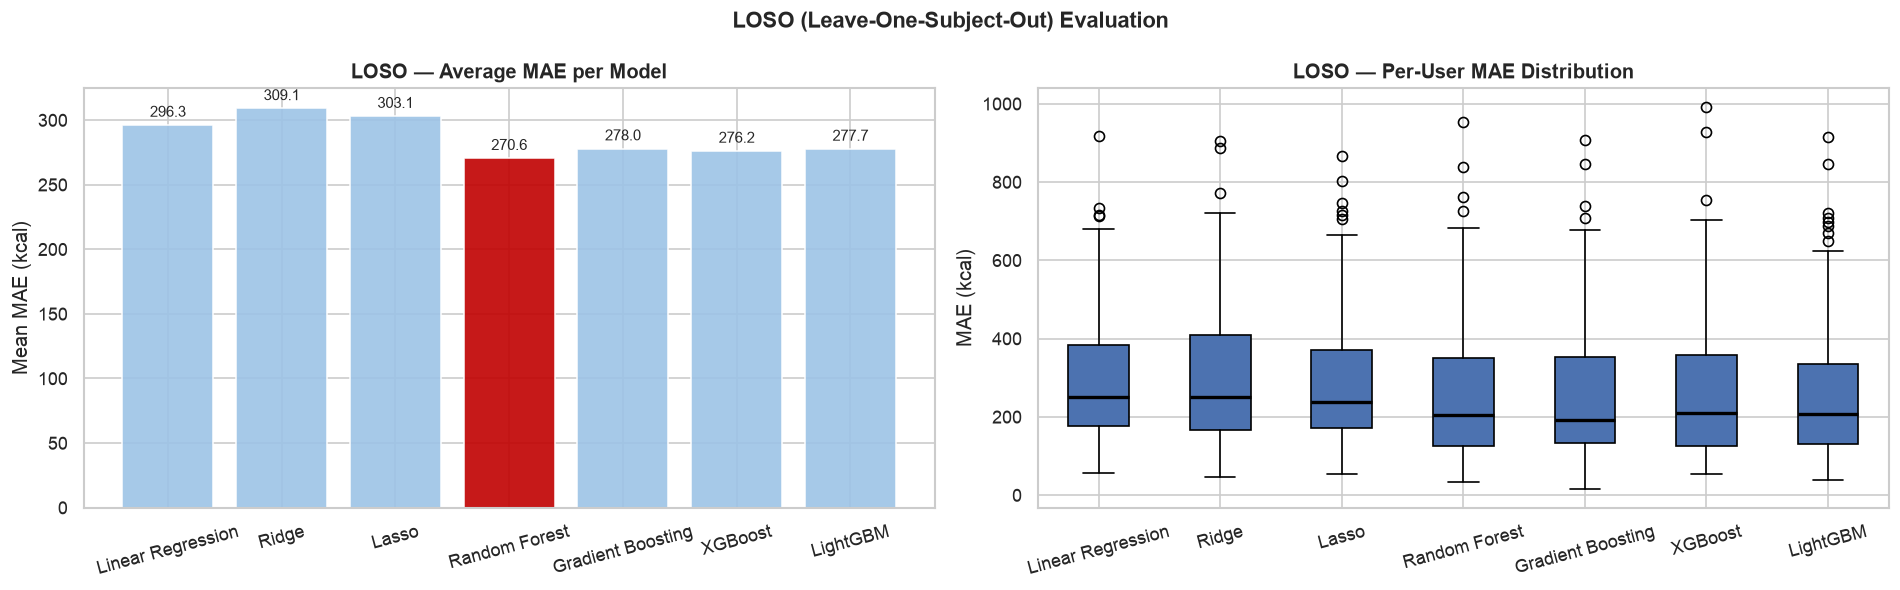

=== LOSO vs Other Strategies (MAE) ===
                   GroupKFold  WU-TSCV  PU-TSCV   LOSO
Model                                                 
Linear Regression       323.7    307.8    137.6  296.3
Ridge                   321.5    306.1     88.2  309.1
Lasso                   310.4    303.3     69.6  303.1
Random Forest           281.1    183.3    119.2  270.6
Gradient Boosting       276.1    201.3    106.0  278.0
XGBoost                 278.9    180.9    117.6  276.2
LightGBM                281.9    177.5    260.2  277.7

GroupKFold → 3-fold, users split across folds (may share users)
WU-TSCV    → within-user temporal CV, shared model
PU-TSCV    → per-user model, temporal CV
LOSO       → strictest: train on ALL other users, test on 1 new user


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ─────────────────────────────────────────────────────────────────
# LOSO — Leave-One-Subject-Out
# train on n-1 users, test on 1 user, repeat for every user
# ─────────────────────────────────────────────────────────────────
unique_users = df['id'].unique()
print(f'Total users: {len(unique_users)}')
print(f'Running LOSO ({len(unique_users)} folds) ...')

loso_results = {name: {'maes': [], 'rmses': [], 'r2s': []} for name in default_models}

for test_user in unique_users:
    train_mask = df['id'] != test_user
    test_mask  = df['id'] == test_user

    X_train, y_train = X[train_mask], y[train_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]

    if len(X_test) == 0:
        continue

    for name in default_models:
        pipe = make_pipe(get_gkf_tuned_model(name))
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        mae  = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        ss_res = np.sum((y_test - y_pred) ** 2)
        ss_tot = np.sum((y_test - y_test.mean()) ** 2)
        r2   = 1 - ss_res / ss_tot if ss_tot > 0 else float('nan')

        loso_results[name]['maes'].append(mae)
        loso_results[name]['rmses'].append(rmse)
        loso_results[name]['r2s'].append(r2)

# ── Summary table ────────────────────────────────────────────────
print('=== LOSO Evaluation (MAE / RMSE / R²) ===')
print(f'{"": <22} {"MAE":>8} {"RMSE":>8} {"R2":>8}')
print('-' * 50)
loso_summary = {}
for name in default_models:
    maes  = loso_results[name]['maes']
    rmses = loso_results[name]['rmses']
    r2s   = [v for v in loso_results[name]['r2s'] if not np.isnan(v)]
    avg_mae  = np.mean(maes)
    avg_rmse = np.mean(rmses)
    avg_r2   = np.mean(r2s) if r2s else float('nan')
    loso_summary[name] = (avg_mae, avg_rmse, avg_r2)
    print(f'{name:<22} {avg_mae:>8.1f} {avg_rmse:>8.1f} {avg_r2:>8.3f}')

# ── Per-user detail ──────────────────────────────────────────────
print('=== Per-User MAE (best model highlighted) ===')
best_model = min(loso_summary, key=lambda n: loso_summary[n][0])
print(f'Best model (lowest avg MAE): {best_model} ({loso_summary[best_model][0]:.1f} kcal)')

per_user_df = pd.DataFrame(
    {name: loso_results[name]['maes'] for name in default_models},
    index=unique_users
)
per_user_df.index.name = 'user_id'
print(per_user_df.round(1).to_string())

# ── Plot: avg MAE per model ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: avg MAE bar chart
model_names = list(default_models.keys())
avg_maes    = [loso_summary[n][0] for n in model_names]
bar_colors  = ['#C00000' if n == best_model else '#9DC3E6' for n in model_names]
bars = axes[0].bar(model_names, avg_maes, color=bar_colors, alpha=0.9)
axes[0].bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
axes[0].set_ylabel('Mean MAE (kcal)')
axes[0].set_title('LOSO — Average MAE per Model', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# Right: per-user MAE box plot
axes[1].boxplot(
    [loso_results[n]['maes'] for n in model_names],
    tick_labels=model_names, patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)
axes[1].set_ylabel('MAE (kcal)')
axes[1].set_title('LOSO — Per-User MAE Distribution', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('LOSO (Leave-One-Subject-Out) Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Compare LOSO vs other strategies ────────────────────────────
print('=== LOSO vs Other Strategies (MAE) ===')
compare_rows = []
for name in default_models:
    compare_rows.append({
        'Model':      name,
        'GroupKFold': summary_df.loc[name, 'GKF MAE (GKF-tuned)'],
        'WU-TSCV':    wu_tscv[name][0],
        'PU-TSCV':    pu_tscv[name][0],
        'LOSO':       loso_summary[name][0],
    })
loso_cmp = pd.DataFrame(compare_rows).set_index('Model')
print(loso_cmp.round(1).to_string())
print()
print('GroupKFold → 3-fold, users split across folds (may share users)')
print('WU-TSCV    → within-user temporal CV, shared model')
print('PU-TSCV    → per-user model, temporal CV')
print('LOSO       → strictest: train on ALL other users, test on 1 new user')


### 8-Way Strategy Comparison — Including LOSO

> รวม LOSO เข้ากับ 7 strategies เดิม เพื่อเปรียบเทียบครบทุกวิธี

## 19. Final Summary — When to Use Each Strategy

| Question | Strategy | Best Model | MAE |
|----------|----------|-----------|-----|
| Brand new user | GroupKFold | Gradient Boosting | 276 kcal |
| Known user, predict future | WU-TSCV | LightGBM | 177.5 kcal |
| Known user, personal model | PU-TSCV | Lasso | 70 kcal |
| Research / strictest test | LOSO | Random Forest | 271 kcal |
| ❌ Never use | KFold | — | — |

> **If you had to pick just one** → **GroupKFold + Gradient Boosting** — most honest and realistic for real-world deployment


In [ ]:
# ── Final Summary — Strategy Comparison ──────────────────────────────────
summary_data = {
    'Strategy':   ['KFold ❌',    'GroupKFold', 'TSCV',             'WU-TSCV',                    'PU-TSCV',                     'LOSO'],
    'Use when':   ['Never',       'Brand new user', 'Future, any user', 'Known user (shared model)', 'Known user (personal model)', 'Research / paper'],
    'Best Model': ['—',           'Gradient Boosting', 'LightGBM',          'LightGBM',            'Lasso',                       'Random Forest'],
    'MAE (kcal)': ['—',           276.1,           210.4,              177.5,                        69.6,                          270.6],
}

summary_final = pd.DataFrame(summary_data).set_index('Strategy')
print('=== Final Summary — When to Use Each Strategy ===')
print(summary_final.to_string())

# ── Plot ──────────────────────────────────────────────────────────────────
plot_data = {
        'GroupKFold
        (new user)':       276.1,
        'TSCV
        (future, any user)':     210.4,
        'WU-TSCV
        (known user
        shared)': 177.5,
        'PU-TSCV
        (known user
        personal)': 69.6,
        'LOSO
        (strictest)':            270.6,
}

colors = ['#ED7D31', '#70AD47', '#9966CC', '#C00000', '#404040']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(plot_data.keys(), plot_data.values(), color=colors, alpha=0.9)
ax.bar_label(bars, fmt='%.1f kcal', padding=5, fontsize=10, fontweight='bold')
ax.set_ylabel('MAE (kcal) — lower is better')
ax.set_title('Final Summary — Best MAE per Strategy\n(KFold excluded — leaky)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, max(plot_data.values()) * 1.2)
ax.axhline(276.1, color='#ED7D31', linestyle='--', alpha=0.4, label='GroupKFold baseline')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print()
print('Recommendation:')
print('  Deploy to new users     → GroupKFold + Gradient Boosting (MAE = 276 kcal)')
print('  Predict known user      → PU-TSCV    + Lasso             (MAE = 70 kcal)')
print('  Research / publication  → LOSO       + Random Forest     (MAE = 271 kcal)')


=== 8-Way Strategy Comparison (MAE) ===
                   KFold  GroupKFold   TSCV  WU-Single  WU-TSCV  PU-Single  PU-TSCV   LOSO
Model                                                                                     
Linear Regression  252.1       323.7  307.8      257.5    307.8      100.4    137.6  296.3
Ridge              252.2       321.5  316.7      284.4    306.1      288.2     88.2  309.1
Lasso              253.0       310.4  306.6      281.0    303.3       79.3     69.6  303.1
ElasticNet         285.7       321.0  308.8      287.1    315.2       94.8    106.7  311.3
Random Forest      109.4       281.1  197.9      125.4    183.3      136.1    119.2  270.6
Gradient Boosting  155.4       276.1  210.4      179.4    201.3       92.9    106.0  278.0
XGBoost            108.6       278.9  187.5      131.0    180.9      121.2    117.6  276.2
LightGBM           105.7       281.9  193.0      144.1    177.5      210.9    260.2  277.7


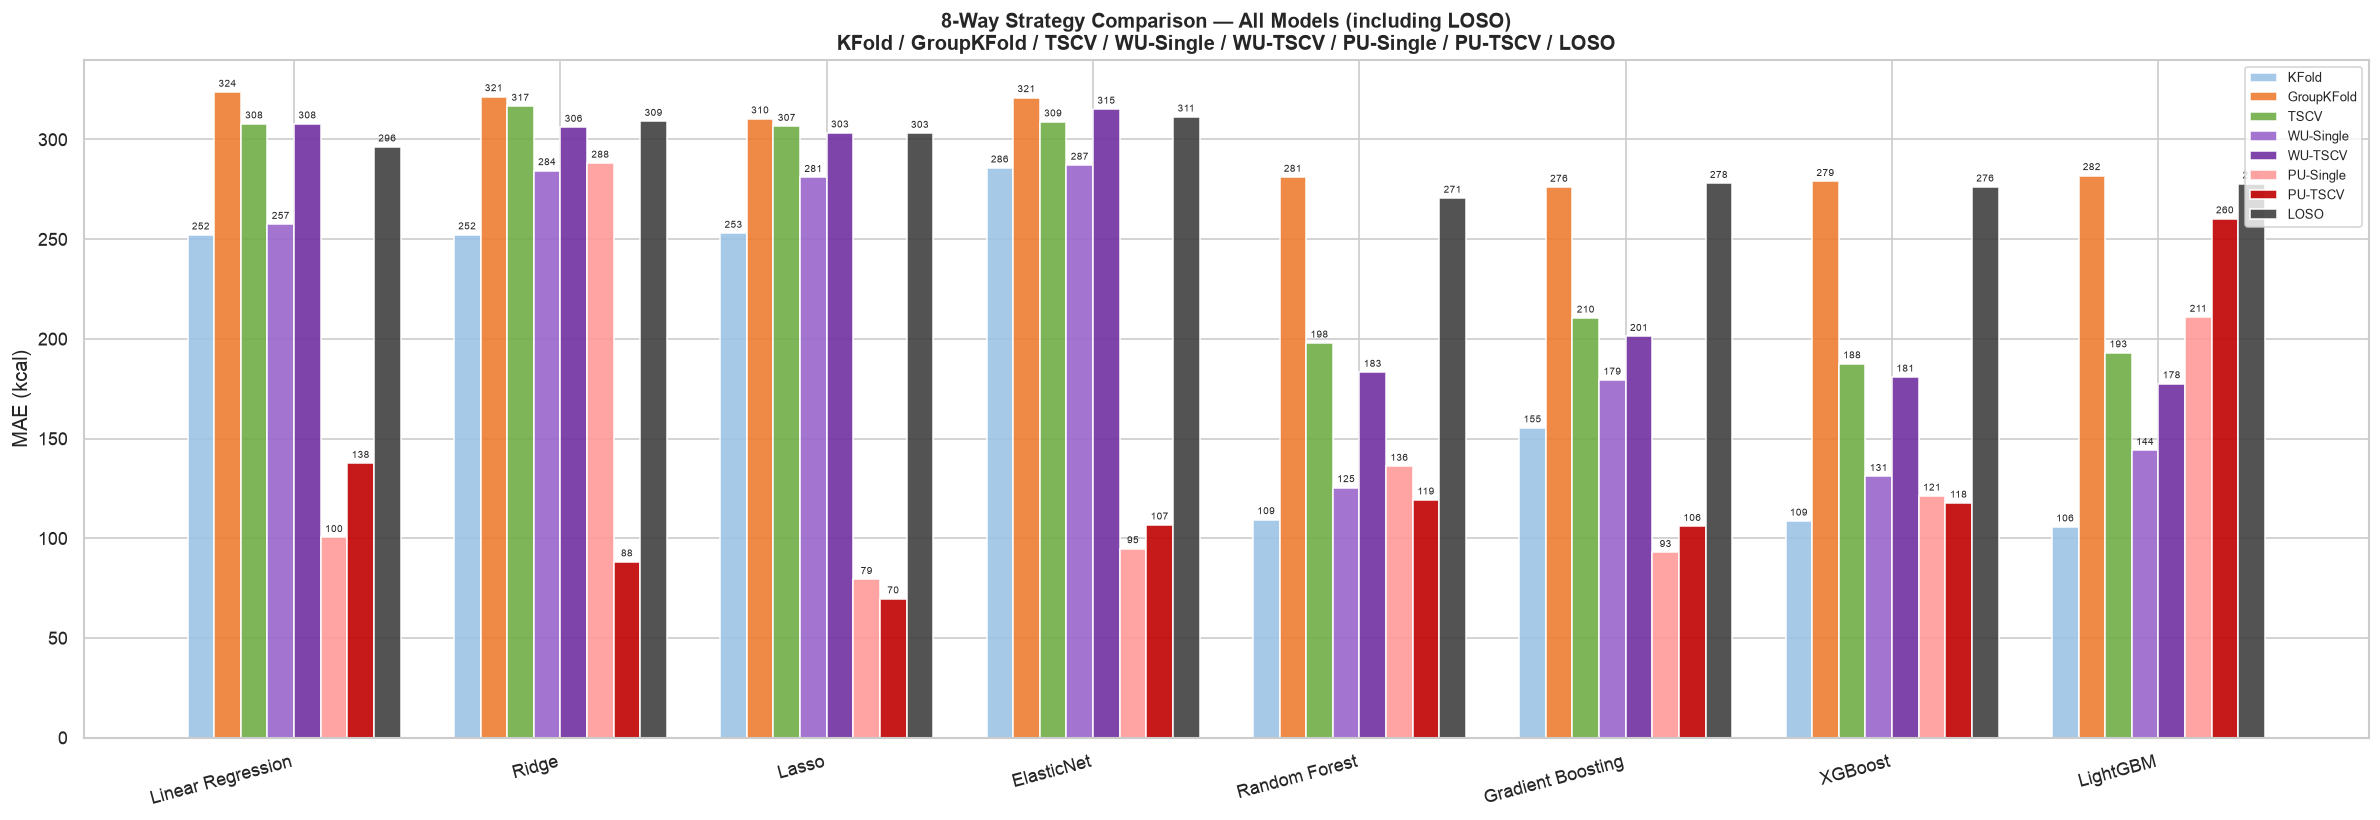


KFold      → leaky ❌
GroupKFold → new user (shared model)
TSCV       → future dates, mixed users
WU-Single  → same user, future dates, shared model
WU-TSCV    → same user, future dates, shared model (CV)
PU-Single  → per-user model
PU-TSCV    → per-user model (CV)
LOSO       → strictest new-user test ← train on ALL others, test on 1


In [48]:
# ── 8-Way Strategy Comparison — รวม LOSO ─────────────────────────────────
rows_8 = []
for name in default_models:
    rows_8.append({
        'Model':      name,
        'KFold':      results[name]['MAE'],
        'GroupKFold': summary_df.loc[name, 'GKF MAE (GKF-tuned)'],
        'TSCV':       tscv_gkf_tuned[name][0],
        'WU-Single':  wu_gkf_tuned[name][0],
        'WU-TSCV':    wu_tscv[name][0],
        'PU-Single':  pu_gkf_tuned[name],
        'PU-TSCV':    pu_tscv[name][0],
        'LOSO':       loso_summary[name][0],
    })

all_cmp_8 = pd.DataFrame(rows_8).set_index('Model')
print('=== 8-Way Strategy Comparison (MAE) ===')
print(all_cmp_8.round(1).to_string())

# ── Plot ──────────────────────────────────────────────────────────────────
strategies = ['KFold', 'GroupKFold', 'TSCV', 'WU-Single', 'WU-TSCV', 'PU-Single', 'PU-TSCV', 'LOSO']
colors     = ['#9DC3E6', '#ED7D31', '#70AD47', '#9966CC', '#7030A0', '#FF9999', '#C00000', '#404040']

fig, ax = plt.subplots(figsize=(20, 7))
x     = np.arange(len(all_cmp_8))
width = 0.10

for i, (strat, color) in enumerate(zip(strategies, colors)):
    offset = (i - len(strategies) / 2 + 0.5) * width
    b = ax.bar(x + offset, all_cmp_8[strat], width, label=strat, color=color, alpha=0.9)
    ax.bar_label(b, fmt='%.0f', padding=2, fontsize=6)

ax.set_xticks(x)
ax.set_xticklabels(all_cmp_8.index, rotation=15, ha='right')
ax.set_ylabel('MAE (kcal)')
ax.set_title('8-Way Strategy Comparison — All Models (including LOSO)\n'
             'KFold / GroupKFold / TSCV / WU-Single / WU-TSCV / PU-Single / PU-TSCV / LOSO',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

print()
print('KFold      → leaky ❌')
print('GroupKFold → new user (shared model)')
print('TSCV       → future dates, mixed users')
print('WU-Single  → same user, future dates, shared model')
print('WU-TSCV    → same user, future dates, shared model (CV)')
print('PU-Single  → per-user model')
print('PU-TSCV    → per-user model (CV)')
print('LOSO       → strictest new-user test ← train on ALL others, test on 1')


## 18. Save Best Models

> บันทึก model ที่ดีที่สุด (GKF-tuned) พร้อม full pipeline (imputer + scaler + model) ลงไฟล์ .joblib
> สามารถโหลดมาทำนายได้ทันทีโดยไม่ต้อง train ใหม่

In [ ]:
import joblib, os, json as _json

# ── Directory for saved models ───────────────────────────────────────────────
MODELS_DIR = os.path.join(os.path.dirname(os.getcwd()), 'saved_models') if 'notebooks' in os.getcwd() else 'saved_models'
os.makedirs(MODELS_DIR, exist_ok=True)

# ── Fit best tuned pipelines on ALL data and save ───────────────────────────
saved_info = {}

for name in default_models:
    pipe = make_pipe(get_gkf_tuned_model(name))
    pipe.fit(X, y)

    safe_name = name.lower().replace(" ", "_")
    filepath = os.path.join(MODELS_DIR, f"{safe_name}_gkf_tuned_full.joblib")
    joblib.dump(pipe, filepath)

    saved_info[name] = {
        "file": filepath,
        "gkf_mae": round(summary_df.loc[name, "GKF MAE (GKF-tuned)"], 2),
        "gkf_r2":  round(float(summary_df.loc[name, "GKF R²"]), 4),
    }
    print(f"Saved: {filepath}")

# ── Save feature list and metadata ──────────────────────────────────────────
meta = {
    "feature_cols": feature_cols,
    "target": "calories",
    "n_samples": len(y),
    "n_users": int(df["id"].nunique()),
    "cv_strategy": "GroupKFold (3 splits, grouped by user)",
    "notebook": "01_calories_regression (full feature set)",
    "models": saved_info,
}
meta_path = os.path.join(MODELS_DIR, "metadata_full.json")
with open(meta_path, "w") as f:
    _json.dump(meta, f, indent=2)
print(f"Saved metadata: {meta_path}")

# ── Summary ──────────────────────────────────────────────────────────────────
print()
print(f"=== Saved {len(saved_info)} models to: {MODELS_DIR} ===")
print(f"{'Model':<25} {'MAE (GKF)':>12} {'R² (GKF)':>10} {'File'}")
print("-" * 80)
for name, info in saved_info.items():
    fname = os.path.basename(info["file"])
    print(f"{name:<25} {info['gkf_mae']:>12.1f} {info['gkf_r2']:>10.4f}  {fname}")